# Wearable HRV and Sleep Efficiency Analysis

**Author:** Xuanyue Zhang  
**M.S. Biological Data Science, Arizona State University**

## Project Overview
This project evaluates whether wearable-derived heart rate variability (HRV)
features can predict nightly sleep efficiency using real-world longitudinal data.

The analysis compares pre-sleep and overnight HRV windows and applies
participant-wise cross-validation, Elastic Net regression, gradient boosting,
and clustering.

**Project Title:** Sleep Efficiency Prediction by HRV features and Cluster Mental Health Profiles Using Real-World Data

**Goal:** Predict nightly sleep efficiency using pre-sleep vs overnight short-term HRV, plus symptom profiles(PHQ-9/GAD-7/ISI)

**Dataset Source:** https://doi.org/10.6084/m9.figshare.28509740  
**Date Files used:** `sensor_hrv.csv`, `sleep_diary.csv`, `survey.csv`

This study will use three datasets that collect average data on healthy individuals from this article (Baigutanova, 2025). It collected data from 49 participants (aged 21-43, including 25 females) over four weeks using **Samsung Galaxy Active 2 smartwatches**. The measurement accuracy of this device had been validated in a prior study (Nissen, 2022). The dataset includes continuous motion recordings with short-term HRV measurements derived from PPG signals, lifestyle data from participants, biweekly clinical questionnaires, and self-reported daily diaries. Details of the three datasets are as follows:  
•	**survey.csv:** It includes participants’ profiles, such as device ID, demographic (age, gender, height, weight, marital status, and occupation), and lifestyle factors. The clinical questionnaire dataset evaluates insomnia using the Insomnia Severity Index (ISI) questionnaire, surveying mental health using PHQ-9 (Patient Health Questionnaire-9) and GAD-7 (General Anxiety Disorder-7) to assess depression and anxiety (Baigutanova, 2025).  
•	**sensor_hrv.csv:** It contains sensor and HRV measurements in 5-minute intervals. The sensor data were aggregated using mean values. Each row has a missingness score column, measuring the level of error in HRV analysis by quantifying the proportion of data within a segment that is affected by signal loss or artifacts during HRV analysis, where a high score indicates greater missing or invalid RR intervals. HRV features include time-domain (SDNN, SDSD, RMSSD, PNN20, PNN50) and frequency-domain (LF, HF, LF/HF) (Baigutanova, 2025).  
•	**sleep_diary.csv:** It includes self-recorded participant sleep schedules. The participants provided estimates, like go-to-bed time, fall-asleep time, wake-up time, and the duration of mid-sleep awake time (WASO), sleep duration, in-bed duration, sleep efficiency, and sleep latency (Baigutanova, 2025).


## Objective 1: Data linkage + "Dataset Overview Table"
To gain a deeper understanding of the data collected from smartwatches across diary and survey questionnaires, I will conduct a comprehensive EDA of these three sources, including 49 participants. This analysis aims to identify trends, patterns, and outliers of core variables. Key metrics such as sleep efficiency, HRV core features, heart rate, health profiles (PHQ-9, GAD-7, ISI). Visualizations, including boxplots, histograms, and tables, were used to reveal relationships between the data and highlight differences across study groups.

### Step 1: Setup and read the three datasets

In [11]:
# Import pandas, numpy, and matplotlib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read three datasets 
sensor = pd.read_csv("sensor_hrv.csv")
diary = pd.read_csv("sleep_diary.csv")
survey = pd.read_csv("survey.csv")

# confirm shapes and first 6 rows of data
print("Sensor shape: ", sensor.shape)
print("Diary shape: ", diary.shape)
print("Survey shape: ", survey.shape)


Sensor shape:  (79639, 28)
Diary shape:  (1372, 11)
Survey shape:  (49, 23)


### Step 2: Inspect columns to identify key columns needed for windowing + modeling


In [13]:
# ============================================================
# Participant ID must match across datasets
# Sensor timestamp (5-min segment start time)
# missingness_score for QC
# HRV core features(RMSSD< SDNN< HR)
# Diar sleep times and sleep_efficiency target
# ============================================================

print("\nSensor columns:\n", sensor.columns.tolist())
print("\nDiary columns:\n", diary.columns.tolist())
print("\nSurvey columns:\n", survey.columns.tolist())


Sensor columns:
 ['deviceId', 'ts_start', 'ts_end', 'missingness_score', 'HR', 'ibi', 'acc_x_avg', 'acc_y_avg', 'acc_z_avg', 'grv_x_avg', 'grv_y_avg', 'grv_z_avg', 'grv_w_avg', 'gyr_x_avg', 'gyr_y_avg', 'gyr_z_avg', 'steps', 'distance', 'calories', 'light_avg', 'sdnn', 'sdsd', 'rmssd', 'pnn20', 'pnn50', 'lf', 'hf', 'lf/hf']

Diary columns:
 ['userId', 'date', 'go2bed', 'asleep', 'wakeup', 'wakeup@night', 'waso', 'sleep_duration', 'in_bed_duration', 'sleep_latency', 'sleep_efficiency']

Survey columns:
 ['deviceId', 'sex', 'age', 'marriage', 'occupation', 'smartwatch', 'regular', 'exercise', 'coffee', 'smoking', 'drinking', 'height', 'weight', 'ISI_1', 'PHQ9_1', 'GAD7_1', 'MEQ', 'ISI_2', 'PHQ9_2', 'GAD7_2', 'ISI_F', 'PHQ9_F', 'GAD7_F']


From the column names above, we can see that the diary dataset uses userId. In contrast, the other two datasets use divicedId, so we need to rename the userId to deviceId so we can link datasets for future analysis.

In [15]:
# rename userId to deviceId in the diary dataset.
diary = diary.rename(columns={"userId": "deviceId"})
print(diary.columns.tolist())

['deviceId', 'date', 'go2bed', 'asleep', 'wakeup', 'wakeup@night', 'waso', 'sleep_duration', 'in_bed_duration', 'sleep_latency', 'sleep_efficiency']


### Step 3: Dataset overview( rows + participants + overlap)

In [20]:
# drop NA in deviceId columns 
sensor_ids =set(sensor["deviceId"].dropna().unique())
diary_ids = set(diary["deviceId"].dropna().unique())
survey_ids = set(survey["deviceId"].dropna().unique())

# table overview
table_overview = pd.DataFrame({
    "Dataset": ["sensor_hrv.csv", "sleep_diary.csv", "survey.csv"],
    "rows": [len(sensor), len(diary), len(survey)],
    "Unique participants": [len(sensor_ids), len(diary_ids), len(survey_ids)]
})

table_overview

,Dataset,rows,Unique participants
0,sensor_hrv.csv,79639,49
1,sleep_diary.csv,1372,49
2,survey.csv,49,49


In [22]:
# overlap
table_overlap =pd.DataFrame({
    "Overlap": ["sensor n diary", "diary n survey", "sensor n survey", "all three"],
    "Participants": [len(sensor_ids & diary_ids), len(diary_ids & survey_ids), len(sensor_ids & survey_ids), len(sensor_ids & diary_ids & survey_ids)]
})
table_overlap

,Overlap,Participants
0,sensor n diary,49
1,diary n survey,49
2,sensor n survey,49
3,all three,49


In [24]:
# Summarize the core variables in the sensor dataset.
sensor_vars = ["missingness_score", "rmssd", "sdnn", "HR", "lf", "hf", "lf/hf"]

rows = []
for v in sensor_vars:
    x = pd.to_numeric(sensor[v], errors="coerce")  # convert safely to numeric
    rows.append({
        "variable": v,
        "N_nonmissing": x.notna().sum(),
        "missing_%": sensor[v].isna().mean() * 100,
        "mean": x.mean(),
        "sd": x.std(),
        "median": x.median(),
        "p25": x.quantile(0.25),
        "p75": x.quantile(0.75),
        "min": x.min(),
        "max": x.max(),
        "n_zero": (x==0).sum(),
        "n_negative":(x<0).sum()
    })

sensor_summary = pd.DataFrame(rows).round(3)
sensor_summary

,variable,N_nonmissing,missing_%,mean,sd,median,p25,p75,min,max,n_zero,n_negative
0,missingness_score,79639,0.000,4.210000e-01,3.170000e-01,0.361,0.151,0.670,-1.189,9.980000e-01,0,1296
1,rmssd,77632,2.520,1.101520e+02,6.367600e+01,93.774,68.132,136.368,0.000,8.558390e+02,2,0
2,sdnn,79639,0.000,9.975200e+01,4.311500e+01,91.277,68.831,124.597,0.000,3.933520e+02,312,0
3,HR,79639,0.000,8.357800e+01,1.574200e+01,81.396,72.935,91.847,39.562,2.002240e+02,0,0
4,lf,78415,1.537,1.759713e+41,4.912686e+43,1283.524,614.088,2409.308,0.000,1.375678e+46,4111,0
5,hf,78415,1.537,6.776321e+42,1.896412e+45,2056.551,962.334,4385.314,0.000,5.310459e+47,1350,0
6,lf/hf,77065,3.232,8.190000e-01,1.157000e+00,0.616,0.384,0.987,0.000,1.261940e+02,2761,0


sensor_hrv contains 79,639 rows, where each row represents a 5-minute segment of wearable-derived measurements for each participant. Sleep_diary dataset contains 1,372 rows, where each row represents a participant-night. The survey dataset contains 49 rows, each row representing a participant. All three datasets include 49 unique participants, and the overlap of participants across tables is complete because 49 participants appear in all datasets. This indicates that the files can be merged cleanly to support the planned analysis.

In [27]:
# Diary core variable summary for night-level outcomes
diary_vars_core = ["sleep_efficiency", "sleep_duration", "waso", "sleep_latency", "in_bed_duration"]

rows = []
for v in diary_vars_core:
    x = pd.to_numeric(diary[v], errors="coerce")
    rows.append({
        "variable": v,
        "N_nonmissing": x.notna().sum(),
        "missing_%": diary[v].isna().mean() * 100,
        "mean": x.mean(),
        "sd": x.std(),
        "median": x.median(),
        "p25": x.quantile(0.25),
        "p75": x.quantile(0.75),
        "min": x.min(),
        "max": x.max()
    })

table_diary_core = pd.DataFrame(rows).round(3)
table_diary_core



,variable,N_nonmissing,missing_%,mean,sd,median,p25,p75,min,max
0,sleep_efficiency,1372,0.000,0.935,0.073,0.955,0.923,0.981,0.468,1.000
1,sleep_duration,1372,0.000,7.807,1.614,7.667,6.750,8.667,2.500,15.833
2,waso,1366,0.437,14.575,35.332,0.000,0.000,10.000,0.000,360.000
3,sleep_latency,1372,0.000,0.564,0.700,0.333,0.167,0.667,0.000,5.417
4,in_bed_duration,1372,0.000,8.370,1.685,8.250,7.238,9.333,2.667,16.000


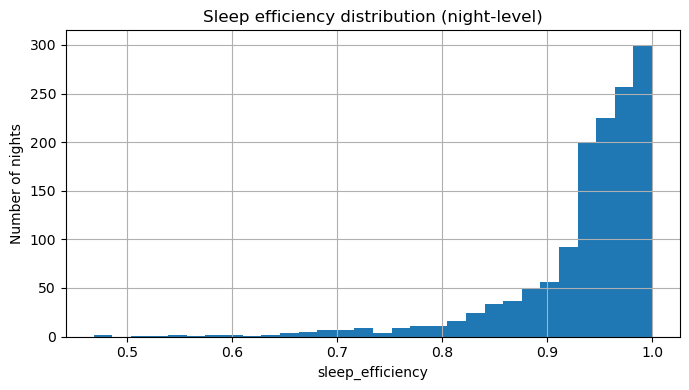

In [30]:
# Sleep efficiency distribution, check range, skew, and outliers
plt.figure(figsize=(7,4))
diary["sleep_efficiency"].dropna().hist(bins=30)
plt.title("Sleep efficiency distribution (night-level)")
plt.xlabel("sleep_efficiency")
plt.ylabel("Number of nights")
plt.tight_layout()
plt.show()

Sleep efficiency is the most important variable, which is complete across all 1,372 nights. Sleep efficiency is bounded between 0 and 1; the mean of sleep efficiency is 0.935. From the plot above, the sleep_efficiency is right-skewed, which shows it is concentrated near the high end. It indicates that this data was collected from a healthy population with generally efficient sleep. Other nightly sleep descriptors (sleep duration, in-bed duration, sleep latency) are also complete, while WASO has a small amount of missingness.

In [33]:
#Survey baseline variables summary for clustering
survey_core_vars = ["age", "PHQ9_1", "GAD7_1", "ISI_1"]
survey_rows =[]
for v in survey_core_vars:
    x = pd.to_numeric(survey[v], errors="coerce")
    survey_rows.append({
         "variable": v,
        "N_nonmissing": x.notna().sum(),
        "missing_%": survey[v].isna().mean() * 100,
        "mean": x.mean(),
        "sd": x.std(),
        "median": x.median(),
        "p25": x.quantile(0.25),
        "p75": x.quantile(0.75),
        "min": x.min(),
        "max": x.max()
    })
table_survey_core = pd.DataFrame(survey_rows).round(3)
table_survey_core    

,variable,N_nonmissing,missing_%,mean,sd,median,p25,p75,min,max
0,age,49,0.0,28.347,5.872,27.0,23.0,32.0,21,43
1,PHQ9_1,49,0.0,3.653,3.620,3.0,1.0,6.0,0,14
2,GAD7_1,49,0.0,3.020,3.461,2.0,0.0,4.0,0,14
3,ISI_1,49,0.0,7.408,4.645,8.0,4.0,10.0,0,20


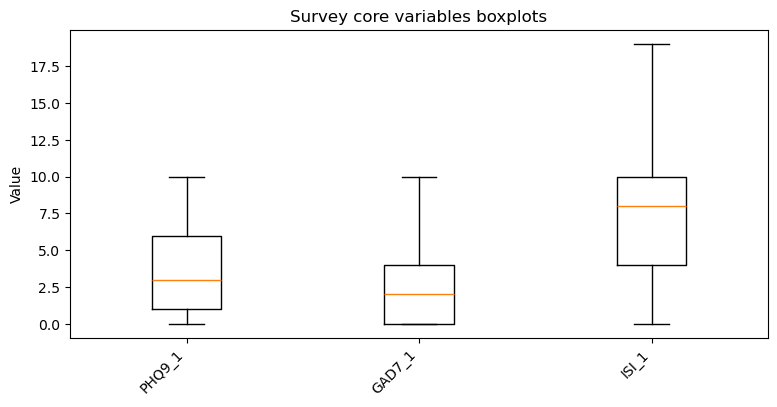

In [35]:
# Plot the core variables in the survey dataset
cols =  ["PHQ9_1", "GAD7_1", "ISI_1"]
survey_data = [pd.to_numeric(survey[c], errors="coerce").dropna() for c in cols]

plt.figure(figsize=(9,4))
plt.boxplot(survey_data, tick_labels=cols, showfliers=False)
plt.title("Survey core variables boxplots")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.show()

The above table and plot are summarized from the survey dataset in participant level. It shows baseline symptom scores are complete for all participants, PHQ9-1, GAD7_1, and ISI_1 have 0% missingness, supporting the planned clustering of symptom profiles. The boxplot shows meaningful variation across participants, especially for ISI_1, which supports the feasibility of identifying distinct mental-health profiles.
Overall, objective 1 confirms that the dataset is well-structured for the proposed pipeline. The three tables link perfectly at the participant level; the sleep diary provides a complete night-level outcome for supervised prediction, and the survey provides complete baseline symptom scores for clustering. The sensor table contains sufficient HRV predictors, but its quality metric (missingness_score) shows variability and occasional anomalies, motivating the QC and coverage feasibility checks addressed in the next two objectives.


## Objective 2: Sensor quality and QC feasibility

### Step 1: missingness_score quality and QC pass rate

In [40]:
# Specifically check missingness_score range
QC_thresh = 0.35
ms = pd.to_numeric(sensor["missingness_score"], errors="coerce")

table_qc=pd.DataFrame({
    "Metric": [
        "Total sensor segments",
        "Non-missing missingness_Score",
        "missingness_score mean",
        "missingness_score median",
        "missingness_score min",
        "missingness_score max",
        "Count missingness_score < 0",
        "Count missingness_score > 1",
        f"QC pass rate (missingness_score <= {QC_thresh})"
    ],
    "Value": [
        len(sensor),
        ms.notna().sum(),
        ms.mean(),
        ms.median(),
        ms.min(),
        ms.max(),
        (ms < 0).sum(),
        (ms >1).sum(),
        (ms.dropna() <=QC_thresh).mean()
    ]
}).round(3)
table_qc

,Metric,Value
0,Total sensor segments,79639.000
1,Non-missing missingness_Score,79639.000
2,missingness_score mean,0.421
3,missingness_score median,0.361
4,missingness_score min,-1.189
5,missingness_score max,0.998
6,Count missingness_score < 0,1296.000
7,Count missingness_score > 1,0.000
8,QC pass rate (missingness_score <= 0.35),0.489


1,296 segments had negative values (none exceeded 1), approximately 48.9% of 5-min segments pass the QC threshold (missingness_score ≤ 0.35), and a small number of segments showed missingness_score values below 0, suggesting occasional calculation artifacts; therefore, we treat missingness_score as a QC indicator and apply the established threshold for segment filtering.  We therefore clipped the score to [0,1] and applied the QC threshold (≤0.35) for segment filtering.”

### step 2: plot missingness_score distribution and threshold

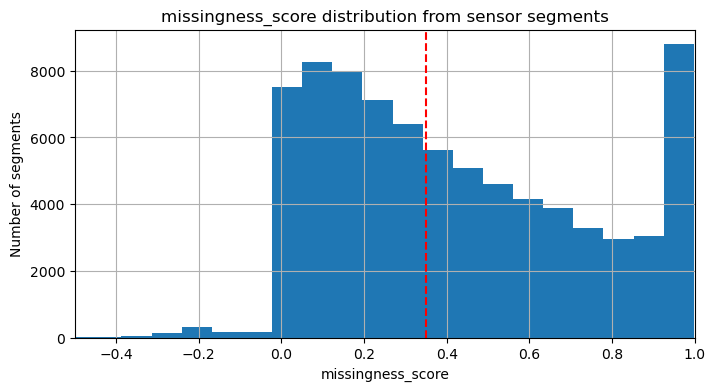

In [44]:
# missingness_score distribution + threshold histgram plot
plt.figure(figsize=(8,4))
ms.dropna().hist(bins=30)
plt.axvline(QC_thresh, linestyle="--", color="red")
plt.title("missingness_score distribution from sensor segments")
plt.xlabel("missingness_score")
plt.ylabel("Number of segments")
plt.xlim(-0.5, 1)          
plt.show()
           

The plot shows that missingness_score spans a wide range and has a large mass near the upper end of the scale, consistent with frequent motion or artifact contamination in a real-world wearable PPG signal. The vertical line at 0.35 highlights that many segments fall above the QC threshold. We therefore clipped the score to [0,1] and applied the QC threshold (≤0.35) for segment filtering.


In [47]:
#QC pass rate by participant level
QC_thresh = 0.35
sensor_tmp = sensor.copy()
sensor_tmp["qc_pass"] = pd.to_numeric(sensor_tmp["missingness_score"], errors="coerce") <= QC_thresh

pass_by_person = sensor_tmp.groupby("deviceId")["qc_pass"].mean().dropna()
table_pass_by_person = pd.DataFrame({
    "Metric": ["Participants", "QC pass rate (min)", "QC pass rate (median)", "QC pass rate (max)"],
    "Value": [
        pass_by_person.shape[0],
        pass_by_person.min(),
        pass_by_person.median(),
        pass_by_person.max()
    ]
}).round(3)

table_pass_by_person

,Metric,Value
0,Participants,49.000
1,QC pass rate (min),0.139
2,QC pass rate (median),0.469
3,QC pass rate (max),0.700


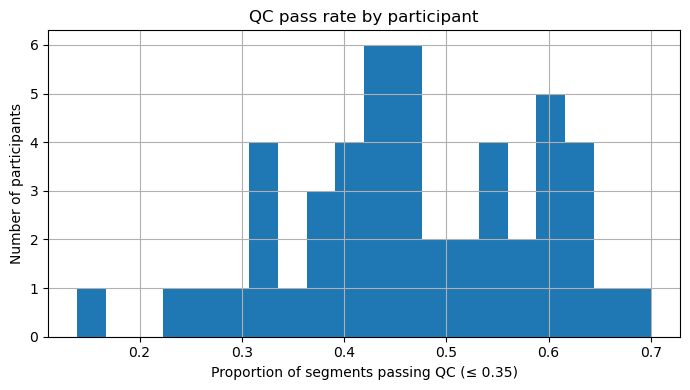

In [49]:
# Plot QC pass rate by participant
plt.figure(figsize=(7,4))
pass_by_person.hist(bins=20)
plt.title("QC pass rate by participant")
plt.xlabel("Proportion of segments passing QC (≤ 0.35)")
plt.ylabel("Number of participants")
plt.tight_layout()
plt.show()

The QC pass rate varies substantially across participants. Across the 49 participants, the minimum participant level pass rate is 0.139, the median is 0.469, and the maximum is 0.700. The Plot shows this distribution clearly, which indicates that some participants consistently produce lower-quality segments than others. This heterogeneity is important for feasibility because participants with low pass rates may contribute to fewer valid nights and could be excluded by the later window-coverage rules.

## Objective 3: Window coverage feasibility

### Step 1: Prepare diary datetimes and cross-midnight fix

In [54]:
# keep only diary rows we can use for windows and targets
diary_clean = diary.dropna(subset=["deviceId", "date", "asleep", "wakeup", "sleep_efficiency"]).copy()
diary_clean["date"] = pd.to_datetime(diary_clean["date"], errors="coerce")

#define function to combine datetime
def combine_date_time(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str), errors="coerce"
    )

diary_clean["asleep_dt"] = combine_date_time(diary_clean["date"], diary_clean["asleep"])
diary_clean["wake_dt"] = combine_date_time(diary_clean["date"], diary_clean["wakeup"])
# Fix cross_midnight wake time(wake_dt earlier than asleep_dt)
mask = diary_clean["wake_dt"] < diary_clean["asleep_dt"]
diary_clean.loc[mask, "wake_dt"] += pd.Timedelta(days=1)

# drop any rows that still failed datetime parsing
diary_clean = diary_clean.dropna(subset=["asleep_dt", "wake_dt"])

print("Usable diary nights after datetime parsing:", len(diary_clean))
print("Participants in diary_clean:", diary_clean["deviceId"].nunique())
diary_clean.head()

Usable diary nights after datetime parsing: 1372
Participants in diary_clean: 49


,deviceId,date,go2bed,asleep,wakeup,wakeup@night,waso,sleep_duration,in_bed_duration,sleep_latency,sleep_efficiency,asleep_dt,wake_dt
0,pm96,2021-03-09,01:00:00,02:00:00,08:30:00,0,0.0,6.500000,7.500000,1.000000,0.866667,2021-03-09 02:00:00,2021-03-09 08:30:00
1,pm96,2021-03-10,00:00:00,00:40:00,07:50:00,0,0.0,7.166667,7.833333,0.666667,0.914894,2021-03-10 00:40:00,2021-03-10 07:50:00
2,pm96,2021-03-11,00:30:00,01:00:00,07:40:00,0,0.0,6.666667,7.166667,0.500000,0.930233,2021-03-11 01:00:00,2021-03-11 07:40:00
3,pm96,2021-03-12,00:30:00,01:00:00,07:50:00,0,0.0,6.833333,7.333333,0.500000,0.931818,2021-03-12 01:00:00,2021-03-12 07:50:00
4,pm96,2021-03-13,01:00:00,01:30:00,10:30:00,0,0.0,9.000000,9.500000,0.500000,0.947368,2021-03-13 01:30:00,2021-03-13 10:30:00


### step 2: QC-filter sensor segments and keep only segments with core HRV available
From the dataset overview, we can see that the ts_start variable in the sensor dataset isepoch timestamp in milliseconds( milliseconds since 1970), so I converted sensor timestamps from epoch milliseconds to datetimes, then applied segment-level QC by clipping the missingness_score to [0,1], and retaining segments with missingness_score ≤ 0.35.

In [57]:

sensor_raw = pd.read_csv("sensor_hrv.csv")
# Convert epoch millisecondsin sensor dataset to datetime
ts = pd.to_numeric(sensor_raw["ts_start"], errors="coerce")
ts_end = pd.to_numeric(sensor_raw["ts_end"], errors="coerce")
sensor_raw["ts_start_dt"] = pd.to_datetime(ts, unit="ms", errors="coerce")
sensor_raw["ts_end_dt"] = pd.to_datetime(ts_end, unit="ms", errors="coerce")
# Now build sensor_qc using the corrected datetime
sensor_qc = sensor_raw.copy()
sensor_qc["ts_start"] = sensor_qc["ts_start_dt"]
sensor_qc["ts_end"] = sensor_qc["ts_end_dt"]
QC_THRESH = 0.35
ms = pd.to_numeric(sensor_qc["missingness_score"], errors="coerce")
sensor_qc["missingness_score_clipped"] = ms.clip(lower=0, upper=1)

sensor_qc = sensor_qc.dropna(subset=["deviceId", "ts_start", "missingness_score_clipped", "rmssd", "sdnn", "HR"])
sensor_qc = sensor_qc[sensor_qc["missingness_score_clipped"] <= QC_THRESH]

print("After QC + core HRV:", sensor_qc.shape)
print("Sensor time range:", sensor_qc["ts_start"].min(), "to", sensor_qc["ts_start"].max())
sensor_qc[["deviceId","ts_start"]].head()


After QC + core HRV: (38913, 31)
Sensor time range: 2018-01-01 20:17:11.436000 to 2021-04-08 03:09:51.127000


,deviceId,ts_start
0,ab60,2021-04-01 07:33:45.031
1,ab60,2021-03-26 05:33:37.151
2,ab60,2021-03-26 05:28:37.083
3,ab60,2021-03-26 05:23:37.077
7,ab60,2021-03-26 04:53:36.800


### Step 3: Compute coverage per night for both the pre-sleep window and the overnight window
I also required non-missing values for core HRV predictors (RMSSD, SDNN, HR). For each sleep diary night (N = 1,372), I counted the number of valid HRV segments within the 2-hour pre-sleep window and within the overnight window. Coverage was computed as:  
Pre-sleep coverage = valid segments / 24   
Overnight coverage = valid segments / expected segments (based on sleep duration / 5 minutes)

In [59]:
# Speed: group by participant
sensor_groups = {pid: g.sort_values("ts_start") for pid, g in sensor_qc.groupby("deviceId")}

PRE_HOURS = 2
PRE_EXPECTED = 24      # 2 hours / 5 min = 24 segments
PRE_MIN_VALID = 18     # >=75%

OVR_MIN_COV = 0.70     # >=70%

rows = []

for _, r in diary_clean.iterrows():
    pid = r["deviceId"]
    if pid not in sensor_groups:
        continue

    s = sensor_groups[pid]
    asleep = r["asleep_dt"]
    wake   = r["wake_dt"]

    # ---- Pre-sleep window ----
    pre_start = asleep - pd.Timedelta(hours=PRE_HOURS)
    pre_end   = asleep
    pre_seg   = s[(s["ts_start"] >= pre_start) & (s["ts_start"] < pre_end)]
    pre_valid = len(pre_seg)
    pre_cov   = pre_valid / PRE_EXPECTED

    # ---- Overnight window ----
    dur_min = (wake - asleep).total_seconds() / 60
    ovr_expected = int(np.floor(dur_min / 5))
    ovr_cov = np.nan
    ovr_valid = np.nan

    if ovr_expected > 0:
        ovr_seg   = s[(s["ts_start"] >= asleep) & (s["ts_start"] < wake)]
        ovr_valid = len(ovr_seg)
        ovr_cov   = ovr_valid / ovr_expected

    rows.append({
        "deviceId": pid,
        "date": r["date"],
        "sleep_efficiency": r["sleep_efficiency"],
        "pre_valid": pre_valid,
        "pre_coverage": pre_cov,
        "ovr_expected": ovr_expected,
        "ovr_valid": ovr_valid,
        "ovr_coverage": ovr_cov
    })

night_cov = pd.DataFrame(rows)

print("Nights with any sensor segments after QC:", len(night_cov))
print("Participants represented:", night_cov["deviceId"].nunique())
night_cov


Nights with any sensor segments after QC: 1372
Participants represented: 49


,deviceId,date,sleep_efficiency,pre_valid,pre_coverage,ovr_expected,ovr_valid,ovr_coverage
0,pm96,2021-03-09,0.866667,7,0.291667,78,24,0.307692
1,pm96,2021-03-10,0.914894,1,0.041667,86,33,0.383721
2,pm96,2021-03-11,0.930233,2,0.083333,80,15,0.187500
3,pm96,2021-03-12,0.931818,0,0.000000,82,10,0.121951
4,pm96,2021-03-13,0.947368,0,0.000000,108,25,0.231481
...,...,...,...,...,...,...,...,...
1367,sc27,2021-04-01,0.957627,0,0.000000,113,0,0.000000
1368,sc27,2021-04-02,0.977778,1,0.041667,88,15,0.170455
1369,sc27,2021-04-03,0.947368,0,0.000000,108,0,0.000000
1370,sc27,2021-04-04,0.964286,0,0.000000,108,0,0.000000


### Step 4: feasibility and retention for pre-sleep and overnight
Evaluated retention under the planned rules: pre-sleep ≥75% coverage (≥18/24) and overnight ≥70% coverage.

In [62]:
pre_kept = night_cov[night_cov["pre_valid"] >= PRE_MIN_VALID].copy()
ovr_kept = night_cov[night_cov["ovr_coverage"] >= OVR_MIN_COV].copy()

coverage_table = pd.DataFrame({
    "Window": ["Pre-sleep (2h)", "Overnight"],
    "Coverage rule": [">=18/24 valid (>=75%)", ">=70% coverage"],
    "Candidate nights": [night_cov["pre_coverage"].notna().sum(), night_cov["ovr_coverage"].notna().sum()],
    "Retained nights": [len(pre_kept), len(ovr_kept)],
    "Retention %": [
        round(len(pre_kept) / max(1, night_cov["pre_coverage"].notna().sum()) * 100, 1),
        round(len(ovr_kept) / max(1, night_cov["ovr_coverage"].notna().sum()) * 100, 1)
    ],
    "Retained participants": [pre_kept["deviceId"].nunique(), ovr_kept["deviceId"].nunique()]
})

coverage_table


,Window,Coverage rule,Candidate nights,Retained nights,Retention %,Retained participants
0,Pre-sleep (2h),>=18/24 valid (>=75%),1372,25,1.8,13
1,Overnight,>=70% coverage,1372,12,0.9,8


We can see that coverage was generally low for both windows. Under the planned feasibility criteria (pre-sleep ≥75% coverage (≥18/24) and overnight ≥70% coverage), only 25 of 1,372 nights (1.8%) met the pre-sleep threshold, and only 12 of 1,372 nights (0.9%) met the overnight threshold. These retained nights represented 13 participants for pre-sleep and 8 participants for overnight. 

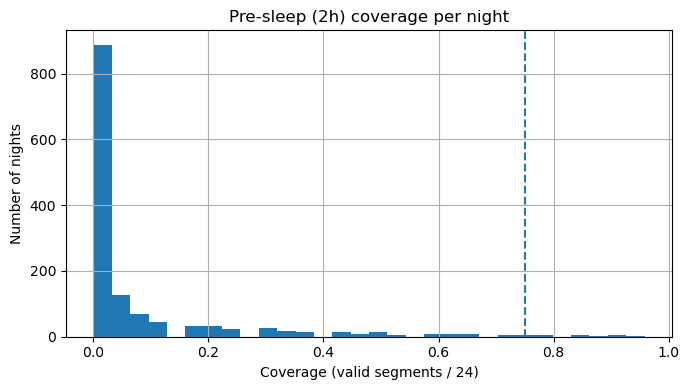

In [64]:
# plot Pre-sleep (2h) HRV coverage per night after QC filtering.
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
night_cov["pre_coverage"].dropna().hist(bins=30)
plt.axvline(0.75, linestyle="--")
plt.title("Pre-sleep (2h) coverage per night")
plt.xlabel("Coverage (valid segments / 24)")
plt.ylabel("Number of nights")
plt.tight_layout()
plt.show()


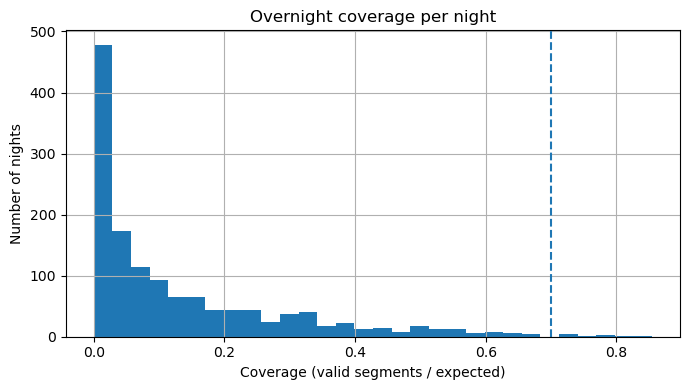

In [65]:
# Plot overnight HRV coverage per night after QC filtering.
plt.figure(figsize=(7,4))
night_cov["ovr_coverage"].dropna().hist(bins=30)
plt.axvline(0.70, linestyle="--")
plt.title("Overnight coverage per night")
plt.xlabel("Coverage (valid segments / expected)")
plt.ylabel("Number of nights")
plt.tight_layout()
plt.show()


The coverage histograms show that most nights have near-zero coverage in both windows, with only a small tail of nights approaching the target thresholds. These findings are very important, as they suggest that HRV segments are sparsely available after QC filtering, within both pre-sleep and overnight windows. The segments remain too few nights based on theoretical five-minute sampling coverage rules. 

In [67]:
thresholds = [0, 1, 2, 3, 5, 8, 10]

rows = []
for k in thresholds:
    kept = night_cov[night_cov["pre_valid"] >= k]
    rows.append({
        "Pre-sleep rule (>=k segments)": k,
        "Retained nights": len(kept),
        "Retention %": round(len(kept) / len(night_cov) * 100, 1),
        "Retained participants": kept["deviceId"].nunique()
    })

pd.DataFrame(rows)

,Pre-sleep rule (>=k segments),Retained nights,Retention %,Retained participants
0,0,1372,100.0,49
1,1,485,35.3,48
2,2,358,26.1,43
3,3,290,21.1,41
4,5,212,15.5,35
5,8,127,9.3,27
6,10,97,7.1,23


In [68]:
thresholds = [0, 1, 2, 5, 10, 15, 20]

rows = []
for k in thresholds:
    kept = night_cov[night_cov["ovr_valid"].fillna(0) >= k]
    rows.append({
        "Overnight rule (>=k segments)": k,
        "Retained nights": len(kept),
        "Retention %": round(len(kept) / len(night_cov) * 100, 1),
        "Retained participants": kept["deviceId"].nunique()
    })

pd.DataFrame(rows)

,Overnight rule (>=k segments),Retained nights,Retention %,Retained participants
0,0,1372,100.0,49
1,1,1072,78.1,49
2,2,977,71.2,49
3,5,756,55.1,49
4,10,559,40.7,44
5,15,409,29.8,39
6,20,325,23.7,35


## Step 5: Create pre-sleep and overnight windows 

In [70]:
# choose HRV features to aggregate
HRV_COLS = ["HR", "sdnn", "sdsd", "rmssd", "pnn20", "pnn50", "lf", "hf", "lf/hf"]
# require at least the core features present at the segment level
sensor_qc = sensor_qc.dropna(subset=["rmssd", "sdnn", "HR"])
sensor_qc


,deviceId,ts_start,ts_end,missingness_score,HR,ibi,acc_x_avg,acc_y_avg,acc_z_avg,grv_x_avg,...,sdsd,rmssd,pnn20,pnn50,lf,hf,lf/hf,ts_start_dt,ts_end_dt,missingness_score_clipped
0,ab60,2021-04-01 07:33:45.031,2021-04-01 07:38:44.833,0.295448,84.592816,728.534374,0.284765,-0.593973,9.195984,-0.094203,...,78.033038,98.417649,0.746269,0.391791,1818.065625,1252.992443,1.450979,2021-04-01 07:33:45.031,2021-04-01 07:38:44.833,0.295448
1,ab60,2021-03-26 05:33:37.151,2021-03-26 05:38:36.986,0.239085,78.589565,781.896913,3.050179,-1.239353,5.790543,-0.211973,...,73.468687,106.602933,0.803704,0.540741,1918.499169,2784.393293,0.689019,2021-03-26 05:33:37.151,2021-03-26 05:38:36.986,0.239085
2,ab60,2021-03-26 05:28:37.083,2021-03-26 05:33:36.952,0.100773,75.620524,812.183910,2.153267,-3.546833,8.499866,-0.628970,...,48.675496,74.504896,0.809816,0.484663,1292.696555,1034.550027,1.249525,2021-03-26 05:28:37.083,2021-03-26 05:33:36.952,0.100773
3,ab60,2021-03-26 05:23:37.077,2021-03-26 05:28:36.883,0.268178,85.813165,769.754943,2.898409,-3.401356,4.606113,-0.249247,...,48.631219,70.615187,0.719178,0.400685,1561.785747,812.118619,1.923101,2021-03-26 05:23:37.077,2021-03-26 05:28:36.883,0.268178
7,ab60,2021-03-26 04:53:36.800,2021-03-26 04:58:36.672,0.043466,76.944500,775.190053,-0.050221,-6.576164,5.377019,0.715893,...,42.104491,66.973170,0.736111,0.450000,3460.217895,1886.157661,1.834533,2021-03-26 04:53:36.800,2021-03-26 04:58:36.672,0.043466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79618,zk41,2021-03-14 16:05:51.497,2021-03-14 16:10:51.303,0.246220,65.536397,955.357204,4.807801,-1.653819,-1.580354,0.169827,...,71.233787,103.785382,0.814815,0.569444,2398.976663,2287.649226,1.048665,2021-03-14 16:05:51.497,2021-03-14 16:10:51.303,0.246220
79619,zk41,2021-03-14 16:10:51.502,2021-03-14 16:15:51.309,0.339678,57.850605,943.549525,7.178785,-2.219444,2.776768,-0.280727,...,108.960638,142.977787,0.835616,0.575342,5977.876931,4930.029492,1.212544,2021-03-14 16:10:51.502,2021-03-14 16:15:51.309,0.339678
79620,zk41,2021-03-14 16:25:51.640,2021-03-14 16:30:51.473,0.037545,55.898726,1078.602052,7.426670,-0.513623,5.921239,-0.843317,...,68.856070,106.702923,0.821970,0.628788,695.458077,2063.201431,0.337077,2021-03-14 16:25:51.640,2021-03-14 16:30:51.473,0.037545
79621,zk41,2021-03-15 05:39:56.304,2021-03-15 05:44:56.197,0.277592,75.857392,832.140507,0.331235,-2.814619,7.396340,-0.054537,...,64.734356,88.297223,0.769874,0.439331,1100.446412,2563.999375,0.429191,2021-03-15 05:39:56.304,2021-03-15 05:44:56.197,0.277592


In [71]:
# show cleaned diary dataset
diary_clean.head()

,deviceId,date,go2bed,asleep,wakeup,wakeup@night,waso,sleep_duration,in_bed_duration,sleep_latency,sleep_efficiency,asleep_dt,wake_dt
0,pm96,2021-03-09,01:00:00,02:00:00,08:30:00,0,0.0,6.500000,7.500000,1.000000,0.866667,2021-03-09 02:00:00,2021-03-09 08:30:00
1,pm96,2021-03-10,00:00:00,00:40:00,07:50:00,0,0.0,7.166667,7.833333,0.666667,0.914894,2021-03-10 00:40:00,2021-03-10 07:50:00
2,pm96,2021-03-11,00:30:00,01:00:00,07:40:00,0,0.0,6.666667,7.166667,0.500000,0.930233,2021-03-11 01:00:00,2021-03-11 07:40:00
3,pm96,2021-03-12,00:30:00,01:00:00,07:50:00,0,0.0,6.833333,7.333333,0.500000,0.931818,2021-03-12 01:00:00,2021-03-12 07:50:00
4,pm96,2021-03-13,01:00:00,01:30:00,10:30:00,0,0.0,9.000000,9.500000,0.500000,0.947368,2021-03-13 01:30:00,2021-03-13 10:30:00


In [72]:
# build two night-level datasets with k ≥ 10
def aggregate_features(df_window, feature_cols):
    out = {}
    for c in feature_cols:
        x = pd.to_numeric(df_window[c], errors="coerce")
        out[f"{c}_mean"] = x.mean()
        out[f"{c}_median"] = x.median()
        out[f"{c}_sd"] = x.std(ddof=1)
    return out


In [73]:
# main builder(windowed + k filter)
def build_night_level(diary_df, sensor_df, window_type, k_min, feature_cols):
    """
    window_type: "pre" (2h before asleep) or "ovr" (asleep->wake)
    k_min: minimum QC-passing segments required within the window
    """
    # speed: group by participant
    sensor_groups = {pid: g.sort_values("ts_start_dt") for pid, g in sensor_df.groupby("deviceId")}

    rows = []
    for _, r in diary_df.iterrows():
        pid = r["deviceId"]
        if pid not in sensor_groups:
            continue

        s = sensor_groups[pid]
        asleep = r["asleep_dt"]
        wake   = r["wake_dt"]

        if window_type == "pre":
            start = asleep - pd.Timedelta(hours=2)
            end   = asleep
        elif window_type == "ovr":
            start = asleep
            end   = wake
        else:
            raise ValueError("window_type must be 'pre' or 'ovr'")

        w = s[(s["ts_start_dt"] >= start) & (s["ts_start_dt"] < end)]
        n_valid = len(w)

        # feasibility rule
        if n_valid < k_min:
            continue

        feats = aggregate_features(w, feature_cols)

        row = {
            "deviceId": pid,
            "date": r["date"],
            "sleep_efficiency": r["sleep_efficiency"],
            "n_valid_segments": n_valid,
            "window": "pre_sleep" if window_type == "pre" else "overnight",
            "k_rule": k_min
        }
        row.update(feats)
        rows.append(row)

    return pd.DataFrame(rows)


In [74]:
# create the two datasets (k = 10)
K1 = 5
K2 = 10
K3 = 15
pre_sleep_k5 = build_night_level(diary_clean, sensor_qc, window_type="pre", k_min=K1, feature_cols=HRV_COLS)
pre_sleep_k10 = build_night_level(diary_clean, sensor_qc, window_type="pre", k_min=K2, feature_cols=HRV_COLS)
overnight_k10 = build_night_level(diary_clean, sensor_qc, window_type="ovr", k_min=K2, feature_cols=HRV_COLS)
overnight_k15 = build_night_level(diary_clean, sensor_qc, window_type="ovr", k_min=K3, feature_cols=HRV_COLS)

print("Pre-sleep k=5:", pre_sleep_k5.shape, "participants:", pre_sleep_k5["deviceId"].nunique())
print("Pre-sleep k=10:", pre_sleep_k10.shape, "participants:", pre_sleep_k10["deviceId"].nunique())
print("Overnight k=10:", overnight_k10.shape, "participants:", overnight_k10["deviceId"].nunique())
print("Overnight k=15:", overnight_k15.shape, "participants:", overnight_k15["deviceId"].nunique())

pre_sleep_k5.head()
pre_sleep_k10.head()
overnight_k10.head()
overnight_k15.head()

Pre-sleep k=5: (212, 33) participants: 35
Pre-sleep k=10: (97, 33) participants: 23
Overnight k=10: (559, 33) participants: 44
Overnight k=15: (409, 33) participants: 39


,deviceId,date,sleep_efficiency,n_valid_segments,window,k_rule,HR_mean,HR_median,HR_sd,sdnn_mean,...,pnn50_sd,lf_mean,lf_median,lf_sd,hf_mean,hf_median,hf_sd,lf/hf_mean,lf/hf_median,lf/hf_sd
0,pm96,2021-03-09,0.866667,24,overnight,15,81.942175,82.580031,4.721774,71.975587,...,0.082621,1260.549269,1179.293753,543.001331,1300.036471,1313.554894,607.874135,1.203345,0.926902,0.895950
1,pm96,2021-03-10,0.914894,33,overnight,15,78.067997,78.912942,6.217562,74.567160,...,0.072017,1044.293501,962.469041,572.466967,1310.463989,1135.974376,683.867345,1.005449,0.800452,0.713131
2,pm96,2021-03-11,0.930233,15,overnight,15,82.121532,82.655346,8.521768,69.439401,...,0.101182,1189.945822,731.840306,1026.295545,989.577631,936.664835,447.300181,1.296793,0.879991,1.068477
3,pm96,2021-03-13,0.947368,25,overnight,15,90.369032,89.200832,7.213977,66.710261,...,0.095346,2582.156493,678.260018,9058.446509,4146.368255,929.292883,14327.527817,0.962957,0.717239,0.849533
4,pm96,2021-03-14,0.945455,39,overnight,15,85.734113,83.846949,8.860287,77.975746,...,0.140865,19067.353887,1055.659864,111350.237555,58891.744887,1128.918489,357895.211553,0.897800,0.834331,0.509630


In [76]:
# save as CSV files
pre_sleep_k5.to_csv("pre_sleep_night_level_k5.csv", index=False)
pre_sleep_k10.to_csv("pre_sleep_night_level_k10.csv", index=False)
overnight_k10.to_csv("overnight_night_level_k10.csv", index=False)
overnight_k15.to_csv("overnight_night_level_k15.csv", index=False)
print("Saved:",
      "pre_sleep_night_level_k5.csv",
      "pre_sleep_night_level_k10.csv",
      "overnight_night_level_k10.csv",
      "overnight_night_level_k10.csv" )


Saved: pre_sleep_night_level_k5.csv pre_sleep_night_level_k10.csv overnight_night_level_k10.csv overnight_night_level_k10.csv


In [78]:
# quick check to confirm I have enough nights per participant
print("Pre-primary nights/participant (describe):")
print(pre_sleep_k5["deviceId"].value_counts().describe())

print("Pre-sens nights/participant (describe):")
print(pre_sleep_k10["deviceId"].value_counts().describe())

print("\nprimary Overnight nights/participant (describe):")
print(overnight_k10["deviceId"].value_counts().describe())

print("\nOvernight nights/participant (describe):")
print(overnight_k15["deviceId"].value_counts().describe())


Pre-primary nights/participant (describe):
count    35.000000
mean      6.057143
std       6.092150
min       1.000000
25%       1.000000
50%       3.000000
75%       9.000000
max      24.000000
Name: count, dtype: float64
Pre-sens nights/participant (describe):
count    23.000000
mean      4.217391
std       4.441094
min       1.000000
25%       1.000000
50%       2.000000
75%       5.500000
max      16.000000
Name: count, dtype: float64

primary Overnight nights/participant (describe):
count    44.000000
mean     12.704545
std       8.379320
min       1.000000
25%       4.000000
50%      11.000000
75%      20.250000
max      26.000000
Name: count, dtype: float64

Overnight nights/participant (describe):
count    39.000000
mean     10.487179
std       8.045502
min       1.000000
25%       3.000000
50%       9.000000
75%      18.500000
max      25.000000
Name: count, dtype: float64


## Step 6: Data Analysis

The primary pre-sleep dataset (k=5) retained 212 participant-nights from 35 participants (median 3 nights/participant; range 1–24). The primary overnight dataset (k=10) retained 559 participant-nights from 44 participants (median 11 nights/participant; range 1–26). Sensitivity analyses using stricter feasibility thresholds reduced the available data: pre-sleep k=10 retained 97 nights from 23 participants (median 2 nights/participant; range 1–16), and overnight k=15 retained 409 nights from 39 participants (median 9 nights/participant; range 1–25). These results indicate substantially greater HRV availability overnight than in the two-hour pre-sleep window, supporting the use of a lower pre-sleep feasibility threshold to maintain participant coverage for participant-wise evaluation. 

In [89]:
# define feature sets
# core features
core_features = [
    "rmssd_mean","rmssd_median","rmssd_sd",
    "sdnn_mean","sdnn_median","sdnn_sd",
    "HR_mean","HR_median","HR_sd"
]
# expanded features 
expanded_features = core_features + [
    "sdsd_mean","sdsd_median","sdsd_sd",
    "pnn20_mean","pnn20_median","pnn20_sd",
    "pnn50_mean","pnn50_median","pnn50_sd",
    "lf_mean","lf_median","lf_sd",
    "hf_mean","hf_median","hf_sd",
    "lf/hf_mean","lf/hf_median","lf/hf_sd"
]


In [90]:
# Night-level dataset retention
def retention_row(df, label):
    counts = df["deviceId"].value_counts()
    return {
        "dataset": label,
        "N_nights": len(df),
        "N_participants": df["deviceId"].nunique(),
        "Median_nights_per_participant": float(counts.median()),
        "Min_nights_per_participant": int(counts.min()),
        "Max_nights_per_participant": int(counts.max()),
    }

retention_table = pd.DataFrame([
    retention_row(pre_sleep_k5,  "Pre-sleep primary (k=5)"),
    retention_row(overnight_k10, "Overnight primary (k=10)"),
    retention_row(pre_sleep_k10, "Pre-sleep sensitivity (k=10)"),
    retention_row(overnight_k15, "Overnight sensitivity (k=15)"),
])

retention_table

,dataset,N_nights,N_participants,Median_nights_per_participant,Min_nights_per_participant,Max_nights_per_participant
0,Pre-sleep primary (k=5),212,35,3.0,1,24
1,Overnight primary (k=10),559,44,11.0,1,26
2,Pre-sleep sensitivity (k=10),97,23,2.0,1,16
3,Overnight sensitivity (k=15),409,39,9.0,1,25


### Modeling primary windows

In [92]:
# Drop participants with too few nights
# Pre-sleep primary: keep participants with ≥2 nights (because median is 3)
# Overnight primary: keep participants with ≥3 nights

def retain_after_rules(night_cov, valid_col, k, min_nights, window_name):
    # keep nights that meet segment threshold
    tmp = night_cov.copy()
    tmp[valid_col] = tmp[valid_col].fillna(0)
    kept_nights = tmp[tmp[valid_col] >= k].copy()

    # keep participants with enough retained nights
    counts = kept_nights["deviceId"].value_counts()
    keep_ids = counts[counts >= min_nights].index
    final = kept_nights[kept_nights["deviceId"].isin(keep_ids)].copy()

    return {
        "Window": window_name,
        "k_segments": k,
        "min_nights_per_participant": min_nights,
        "Retained_nights": len(final),
        "Retained_participants": final["deviceId"].nunique(),
        "Median_nights_per_participant": final["deviceId"].value_counts().median() if len(final)>0 else 0
    }

summary = pd.DataFrame([
    retain_after_rules(night_cov, valid_col="pre_valid", k=5,  min_nights=2, window_name="Pre-sleep (2h)"),
    retain_after_rules(night_cov, valid_col="ovr_valid", k=10, min_nights=3, window_name="Overnight")
])

summary


,Window,k_segments,min_nights_per_participant,Retained_nights,Retained_participants,Median_nights_per_participant
0,Pre-sleep (2h),5,2,202,25,6.0
1,Overnight,10,3,554,40,13.5


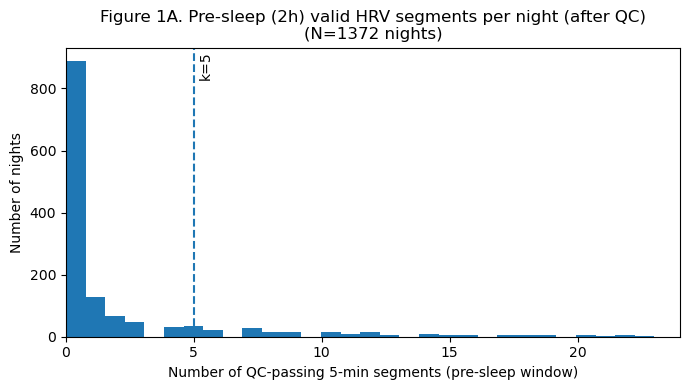

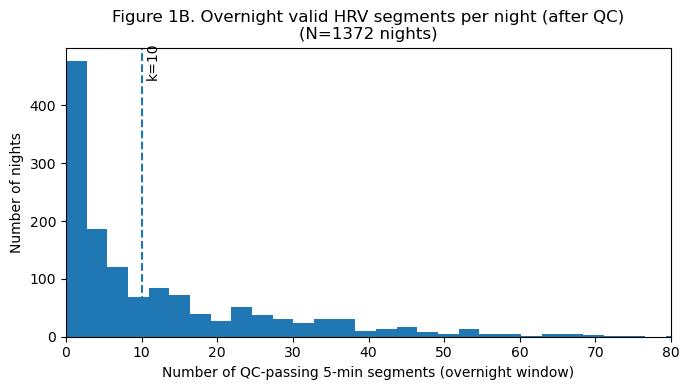

In [93]:
import matplotlib.pyplot as plt

# --- Pre-sleep ---
plt.figure(figsize=(7,4))
x = night_cov["pre_valid"].fillna(0)
plt.hist(x, bins=30)
plt.axvline(5, linestyle="--")
plt.text(5+0.2, plt.ylim()[1]*0.9, "k=5", rotation=90)

plt.title(f"Figure 1A. Pre-sleep (2h) valid HRV segments per night (after QC)\n(N={len(night_cov)} nights)")
plt.xlabel("Number of QC-passing 5-min segments (pre-sleep window)")
plt.ylabel("Number of nights")
plt.xlim(0, 24)
plt.tight_layout()
plt.show()

# --- Overnight ---
plt.figure(figsize=(7,4))
x = night_cov["ovr_valid"].fillna(0)
plt.hist(x, bins=30)
plt.axvline(10, linestyle="--")
plt.text(10+0.5, plt.ylim()[1]*0.9, "k=10", rotation=90)

plt.title(f"Figure 1B. Overnight valid HRV segments per night (after QC)\n(N={len(night_cov)} nights)")
plt.xlabel("Number of QC-passing 5-min segments (overnight window)")
plt.ylabel("Number of nights")
plt.xlim(0, 80)  # or 60 if you want less tail
plt.tight_layout()
plt.show()



### result
After HRV segment QC (missingness_score ≤0.35) and feasibility filtering, the pre-sleep window (k≥5 segments and ≥2 retained nights per participant) retained 202 nights from 25 participants (median 6 nights/participant), whereas the overnight window (k≥10 segments and ≥3 retained nights per participant) retained 554 nights from 40 participants (median 13.5 nights/participant), indicating substantially higher feasibility for overnight HRV.


In [95]:
# modeling: GroupKFold CV on primaty datasets and run ElastiC Net + XGBoost with participant-wise folds
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error
import xgboost
from xgboost import XGBRegressor
print("xgboost version:", xgboost.__version__)


# Drop participants with too few nights
# Pre-sleep primary: keep participants with ≥2 nights (because median is 3)
# Overnight primary: keep participants with ≥3 nights
def filter_min_nights(df, min_nights):
    counts = df["deviceId"].value_counts()
    keep_ids = counts[counts >= min_nights].index
    return df[df["deviceId"].isin(keep_ids)].copy()

pre_main = filter_min_nights(pre_sleep_k5, min_nights=2)
ovr_main = filter_min_nights(overnight_k10, min_nights=3)

print("Pre-sleep main after >=3 nights:", pre_main.shape, pre_main["deviceId"].nunique())
print("Overnight main after >=3 nights:", ovr_main.shape, ovr_main["deviceId"].nunique())

pre_main["sleep_efficiency"].describe()

xgboost version: 3.2.0
Pre-sleep main after >=3 nights: (202, 33) 25
Overnight main after >=3 nights: (554, 33) 40


count    202.000000
mean       0.933032
std        0.071517
min        0.480000
25%        0.918741
50%        0.951800
75%        0.977273
max        1.000000
Name: sleep_efficiency, dtype: float64

### result:
Window feasibility and retained samples
After segment-level QC (missingness_score ≤ 0.35), nightly HRV window feasibility was defined using minimum observed segment counts. The pre-sleep window required ≥5 valid segments and ≥2 retained nights per participant, yielding 202 nights from 25 participants. The overnight window required ≥10 valid segments and ≥3 retained nights per participant, yielding 554 nights from 40 participants. These retained samples indicate that overnight HRV is substantially more feasible than pre-sleep HRV in this dataset, both in the number of retained nights and participants.

In [97]:
# define groupkfold_eval + summarize_cv
def groupkfold_eval_EN_xgb(df, feature_cols, target="sleep_efficiency", group_col="deviceId", n_splits=5):
    X = df[feature_cols].copy()
    y = df[target].astype(float).values
    groups = df[group_col].values

    gkf = GroupKFold(n_splits=n_splits)

    enet = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=0, max_iter=10000))
    ])

    xgb = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=0,
            n_jobs=-1
        ))
    ])

    results = {"ElasticNet": [], "XGBoost": []}

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups), 1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[tr], y[te]

        for name, model in [("ElasticNet", enet), ("XGBoost", xgb)]:
            model.fit(Xtr, ytr)
            pred = model.predict(Xte)

            results[name].append({
                "fold": fold,
                "MAE": mean_absolute_error(yte, pred),
                "RMSE": root_mean_squared_error(yte, pred),
                "R2": r2_score(yte, pred),
                "test_participants": len(np.unique(groups[te])),
                "test_nights": len(te)
            })

    return {k: pd.DataFrame(v) for k, v in results.items()}

def summarize_cv(df_metrics):
    return df_metrics[["MAE","RMSE","R2"]].agg(["mean","std"]).round(4)

In [98]:
# run participant-wise modeling on primary datasets
# use the core feature set first and run Elastic Net, XGBoost, and 5-fold GroupkfOLD
# Since pre-main ends up with <25 participant after filtering, use 4 folds instead of 5

# Choose folds based on participant count
n_splits_pre = 5 if pre_main["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_main["deviceId"].nunique() >= 25 else 4

res_pre = groupkfold_eval_EN_xgb(pre_main, core_features, n_splits=n_splits_pre)
res_ovr = groupkfold_eval_EN_xgb(ovr_main, core_features, n_splits=n_splits_ovr)

print("Pre-sleep ElasticNet:\n", summarize_cv(res_pre["ElasticNet"]))
print("Pre-sleep XGBoost:\n", summarize_cv(res_pre["XGBoost"]))

print("Overnight ElasticNet:\n", summarize_cv(res_ovr["ElasticNet"]))
print("Overnight XGBoost:\n", summarize_cv(res_ovr["XGBoost"]))


Pre-sleep ElasticNet:
          MAE    RMSE      R2
mean  0.0481  0.0710 -0.0993
std   0.0070  0.0167  0.1213
Pre-sleep XGBoost:
          MAE    RMSE      R2
mean  0.0631  0.0873 -0.7248
std   0.0105  0.0162  0.4752
Overnight ElasticNet:
         MAE    RMSE      R2
mean  0.041  0.0632 -0.0545
std   0.007  0.0147  0.0588
Overnight XGBoost:
          MAE    RMSE      R2
mean  0.0509  0.0739 -0.5240
std   0.0070  0.0149  0.6089


Result: Using participant-wise 5-fold GroupKFold cross-validation and the core HRV feature set (RMSSD, SDNN, and mean HR aggregated within each window), Elastic Net showed better generalization performance than XGBoost for both windows. The overnight Elastic Net model achieved the lowest error (MAE 0.041±0.007; RMSE 0.063±0.015), whereas pre-sleep Elastic Net showed higher error (MAE 0.048±0.007; RMSE 0.071±0.017). XGBoost yielded higher errors in both windows (pre-sleep MAE 0.064±0.010; overnight MAE 0.051±0.007), suggesting limited benefit from nonlinear modeling under the current feature set and sample size. R² values were near or below zero across models, indicating limited improvement over a mean baseline under strict participant-wise generalization, consistent with the right-skewed distribution of sleep efficiency and the sparse availability of QC-passing HRV segments in the pre-sleep window.

In [100]:
## Verify expanded features exist
missing_pre = [c for c in expanded_features if c not in pre_main.columns]
missing_ovr = [c for c in expanded_features if c not in ovr_main.columns]

print("Missing in pre_main:", missing_pre)
print("Missing in ovr_main:", missing_ovr)


Missing in pre_main: []
Missing in ovr_main: []


In [101]:
# run participant-wise modeling with expanded features
n_splits_pre = 5 if pre_main["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_main["deviceId"].nunique() >= 25 else 4

res_pre_exp = groupkfold_eval_EN_xgb(pre_main, expanded_features, n_splits=n_splits_pre)
res_ovr_exp = groupkfold_eval_EN_xgb(ovr_main, expanded_features, n_splits=n_splits_ovr)

print("Pre-sleep ElasticNet (expanded):\n", summarize_cv(res_pre_exp["ElasticNet"]))
print("Pre-sleep XGBoost (expanded):\n", summarize_cv(res_pre_exp["XGBoost"]))

print("Overnight ElasticNet (expanded):\n", summarize_cv(res_ovr_exp["ElasticNet"]))
print("Overnight XGBoost (expanded):\n", summarize_cv(res_ovr_exp["XGBoost"]))


Pre-sleep ElasticNet (expanded):
          MAE    RMSE      R2
mean  0.0481  0.0710 -0.0993
std   0.0070  0.0167  0.1213
Pre-sleep XGBoost (expanded):
          MAE    RMSE      R2
mean  0.0629  0.0866 -0.7106
std   0.0066  0.0127  0.4032
Overnight ElasticNet (expanded):
         MAE    RMSE      R2
mean  0.041  0.0632 -0.0545
std   0.007  0.0147  0.0588
Overnight XGBoost (expanded):
          MAE    RMSE      R2
mean  0.0539  0.0792 -0.8652
std   0.0091  0.0148  1.1097


In [102]:
# Create a clean comparison table for core vs expanded
def pack_results(name, res_core, res_exp, model_key):
    core = summarize_cv(res_core[model_key]).loc["mean"]
    exp  = summarize_cv(res_exp[model_key]).loc["mean"]
    return pd.DataFrame({
        "Setting": [name],
        f"{model_key}_MAE_core": [core["MAE"]],
        f"{model_key}_MAE_exp": [exp["MAE"]],
        f"{model_key}_RMSE_core": [core["RMSE"]],
        f"{model_key}_RMSE_exp": [exp["RMSE"]],
        f"{model_key}_R2_core": [core["R2"]],
        f"{model_key}_R2_exp": [exp["R2"]],
    })

compare_elastic = pd.concat([
    pack_results("Pre-sleep", res_pre, res_pre_exp, "ElasticNet"),
    pack_results("Overnight", res_ovr, res_ovr_exp, "ElasticNet"),
], ignore_index=True)

compare_xgb = pd.concat([
    pack_results("Pre-sleep", res_pre, res_pre_exp, "XGBoost"),
    pack_results("Overnight", res_ovr, res_ovr_exp, "XGBoost"),
], ignore_index=True)

print("ElasticNet core vs expanded:")
display(compare_elastic.round(4))

print("XGBoost core vs expanded:")
display(compare_xgb.round(4))


ElasticNet core vs expanded:


,Setting,ElasticNet_MAE_core,ElasticNet_MAE_exp,ElasticNet_RMSE_core,ElasticNet_RMSE_exp,ElasticNet_R2_core,ElasticNet_R2_exp
0,Pre-sleep,0.0481,0.0481,0.0710,0.0710,-0.0993,-0.0993
1,Overnight,0.0410,0.0410,0.0632,0.0632,-0.0545,-0.0545


XGBoost core vs expanded:


,Setting,XGBoost_MAE_core,XGBoost_MAE_exp,XGBoost_RMSE_core,XGBoost_RMSE_exp,XGBoost_R2_core,XGBoost_R2_exp
0,Pre-sleep,0.0631,0.0629,0.0873,0.0866,-0.7248,-0.7106
1,Overnight,0.0509,0.0539,0.0739,0.0792,-0.5240,-0.8652


result: Expanding the HRV feature set beyond RMSSD, SDNN, and mean HR did not improve Elastic Net performance in either window; MAE, RMSE, and R² were unchanged for both pre-sleep and overnight models. For XGBoost, expanded features yielded a small improvement in the pre-sleep setting (MAE 0.0638→0.0632), but performance degraded in the overnight setting (MAE 0.0511→0.0539; RMSE 0.0742→0.0796). Overall, the results suggest that the core features capture most of the predictive signal available in this dataset, while additional HRV metrics provide limited benefit and may reduce generalization for nonlinear boosting models.

In [104]:
## add predict mean sleep efficiency baseline
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def baseline_mean_groupkfold_EN_gxb(df, target="sleep_efficiency", group_col="deviceId", n_splits=5):
    y = df[target].values
    groups = df[group_col].values
    gkf = GroupKFold(n_splits=n_splits)
    out = []
    for fold, (tr, te) in enumerate(gkf.split(df, y, groups), 1):
        ytr, yte = y[tr], y[te]
        pred = np.full_like(yte, fill_value=np.mean(ytr), dtype=float)
        out.append({
            "fold": fold,
            "MAE": mean_absolute_error(yte, pred),
            "RMSE": np.sqrt(mean_squared_error(yte, pred)),
            "R2": r2_score(yte, pred)
        })
    return pd.DataFrame(out)

baseline_ovr = baseline_mean_groupkfold_EN_gxb(ovr_main, n_splits=5)
baseline_pre = baseline_mean_groupkfold_EN_gxb(pre_main, n_splits=5)

print("Baseline (overnight):\n", baseline_ovr[["MAE","RMSE","R2"]].agg(["mean","std"]).round(4))
print("Baseline (pre-sleep):\n", baseline_pre[["MAE","RMSE","R2"]].agg(["mean","std"]).round(4))


Baseline (overnight):
         MAE    RMSE      R2
mean  0.041  0.0632 -0.0545
std   0.007  0.0147  0.0588
Baseline (pre-sleep):
          MAE    RMSE      R2
mean  0.0481  0.0710 -0.0993
std   0.0070  0.0167  0.1213


In [105]:
# Fit Elastic Net on the full overnight dataset for interpretation
best_df = ovr_main
best_features = core_features

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=0, max_iter=10000))
])

X = best_df[best_features]
y = best_df["sleep_efficiency"].astype(float)

pipe.fit(X, y)

coefs = pipe.named_steps["model"].coef_
coef_table = pd.DataFrame({"feature": best_features, "coef": coefs})
coef_table["abs_coef"] = coef_table["coef"].abs()
coef_table.sort_values("abs_coef", ascending=False)

,feature,coef,abs_coef
0,rmssd_mean,0.0,0.0
1,rmssd_median,0.0,0.0
2,rmssd_sd,-0.0,0.0
3,sdnn_mean,0.0,0.0
4,sdnn_median,0.0,0.0
5,sdnn_sd,0.0,0.0
6,HR_mean,-0.0,0.0
7,HR_median,-0.0,0.0
8,HR_sd,-0.0,0.0


###  GroupKFold evaluation with ElasticNetCV and XGBoost

In [107]:
## Define a new GroupKFold evaluation with ElasticNetCV and XGBoost
from sklearn.linear_model import ElasticNetCV
def groupkfold_eval_enetcv_xgb(df, feature_cols, target="sleep_efficiency", group_col="deviceId", n_splits=5):
    X = df[feature_cols].copy()
    y = df[target].astype(float).values
    groups = df[group_col].values

    gkf = GroupKFold(n_splits=n_splits)

    # ElasticNet with internal CV (tunes alpha and l1_ratio)
    enetcv = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.5, 0.9],
            alphas=np.logspace(-4, 0, 30),   # 1e-4 to 1
            cv=5,
            random_state=0,
            max_iter=20000
        ))
    ])

    # XGBoost (same as before)
    xgb = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=0,
            n_jobs=-1
        ))
    ])

    results = {"ElasticNetCV": [], "XGBoost": []}

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups), 1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[tr], y[te]

        for name, model in [("ElasticNetCV", enetcv), ("XGBoost", xgb)]:
            model.fit(Xtr, ytr)
            pred = model.predict(Xte)

            results[name].append({
                "fold": fold,
                "MAE": mean_absolute_error(yte, pred),
                "RMSE": np.sqrt(mean_squared_error(yte, pred)),
                "R2": r2_score(yte, pred),
                "test_participants": len(np.unique(groups[te])),
                "test_nights": len(te)
            })

    return {k: pd.DataFrame(v) for k, v in results.items()}

def summarize_cv(df_metrics):
    return df_metrics[["MAE","RMSE","R2"]].agg(["mean","std"]).round(4)


In [109]:
# re-run primary modeling using core features
n_splits_pre = 5 if pre_main["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_main["deviceId"].nunique() >= 25 else 4

res_pre_cv = groupkfold_eval_enetcv_xgb(pre_main, core_features, n_splits=n_splits_pre)
res_ovr_cv = groupkfold_eval_enetcv_xgb(ovr_main, core_features, n_splits=n_splits_ovr)

print("Pre-sleep ElasticNetCV:\n", summarize_cv(res_pre_cv["ElasticNetCV"]))
print("Pre-sleep XGBoost:\n", summarize_cv(res_pre_cv["XGBoost"]))

print("Overnight ElasticNetCV:\n", summarize_cv(res_ovr_cv["ElasticNetCV"]))
print("Overnight XGBoost:\n", summarize_cv(res_ovr_cv["XGBoost"]))


Pre-sleep ElasticNetCV:
          MAE    RMSE      R2
mean  0.0481  0.0710 -0.0993
std   0.0070  0.0167  0.1213
Pre-sleep XGBoost:
          MAE    RMSE      R2
mean  0.0631  0.0873 -0.7248
std   0.0105  0.0162  0.4752
Overnight ElasticNetCV:
          MAE    RMSE      R2
mean  0.0422  0.0648 -0.1214
std   0.0074  0.0136  0.1551
Overnight XGBoost:
          MAE    RMSE      R2
mean  0.0509  0.0739 -0.5240
std   0.0070  0.0149  0.6089


In [112]:
## extract interpretable coefficients with tuned alpha. fit ElasticNetCV on the full overnight dataset
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV

enetcv_fit = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 0, 30),
        cv=5,
        random_state=0,
        max_iter=20000
    ))
])

X = ovr_main[core_features]
y = ovr_main["sleep_efficiency"].astype(float)

enetcv_fit.fit(X, y)

best_alpha = enetcv_fit.named_steps["model"].alpha_
best_l1 = enetcv_fit.named_steps["model"].l1_ratio_
coefs = enetcv_fit.named_steps["model"].coef_

coef_table = pd.DataFrame({"feature": core_features, "coef": coefs})
coef_table["abs_coef"] = coef_table["coef"].abs()

print("ElasticNetCV chosen alpha:", best_alpha)
print("ElasticNetCV chosen l1_ratio:", best_l1)

coef_table.assign(coef=coef_table["coef"].map(lambda v: f"{v:.8f}"),
                  abs_coef=coef_table["abs_coef"].map(lambda v: f"{v:.8f}"))





ElasticNetCV chosen alpha: 1.0
ElasticNetCV chosen l1_ratio: 0.1


,feature,coef,abs_coef
0,rmssd_mean,0.00000000,0.00000000
1,rmssd_median,0.00000000,0.00000000
2,rmssd_sd,-0.00000000,0.00000000
3,sdnn_mean,0.00000000,0.00000000
4,sdnn_median,0.00000000,0.00000000
5,sdnn_sd,0.00000000,0.00000000
6,HR_mean,-0.00000000,0.00000000
7,HR_median,-0.00000000,0.00000000
8,HR_sd,-0.00000000,0.00000000


### result
ElasticNetCV selected strong regularization and shrank HRV coefficients toward zero, suggesting no stable linear association between aggregated HRV features and sleep efficiency across unseen participants
ElasticNetCV selected strong regularization (α=1.0, l1_ratio=0.1) and shrank all HRV coefficients to approximately zero, indicating that aggregated HRV features (RMSSD, SDNN, HR) provided little incremental predictive value for sleep efficiency under participant-wise evaluation. Cross-validated performance for ElasticNetCV was similar to a mean baseline, while XGBoost did not improve generalization and showed worse MAE. Using participant-wise GroupKFold cross-validation, ElasticNetCV achieved MAE 0.048±0.007 for pre-sleep and MAE 0.042±0.007 for overnight. However, ElasticNetCV coefficients were approximately zero, suggesting limited predictive signal from HRV features alone. XGBoost performed worse (pre-sleep MAE 0.064±0.010; overnight MAE 0.051±0.007), consistent with overfitting/noise under strict generalization.

### discussion
The absence of non-zero coefficients suggests limited cross-person predictive signal from HRV features for sleep efficiency, likely due to the right-skewed distribution of sleep efficiency, sparse/noisy HRV availability in fixed windows, and substantial between-person heterogeneity.

In [118]:
# build a final results table (baseline vs ElasticNetCV vs XGBoost)
def baseline_mean_groupkfold(df, target="sleep_efficiency", group_col="deviceId", n_splits=5):
    y = df[target].astype(float).values
    groups = df[group_col].values
    gkf = GroupKFold(n_splits=n_splits)
    out = []
    for fold, (tr, te) in enumerate(gkf.split(df, y, groups), 1):
        ytr, yte = y[tr], y[te]
        pred = np.full_like(yte, fill_value=np.mean(ytr), dtype=float)
        out.append({
            "fold": fold,
            "MAE": mean_absolute_error(yte, pred),
            "RMSE": np.sqrt(mean_squared_error(yte, pred)),
            "R2": r2_score(yte, pred)
        })
    return pd.DataFrame(out)

def mean_sd(metrics_df):
    s = metrics_df[["MAE","RMSE","R2"]].agg(["mean","std"]).round(4)
    return s

In [119]:
# run baseline and models for core features
n_splits_pre = 5 if pre_main["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_main["deviceId"].nunique() >= 25 else 4

# Baselines
base_pre = baseline_mean_groupkfold(pre_main, n_splits=n_splits_pre)
base_ovr = baseline_mean_groupkfold(ovr_main, n_splits=n_splits_ovr)

# Models (already computed as res_pre_cv, res_ovr_cv)
# res_pre_cv: {"ElasticNetCV": df, "XGBoost": df}
# res_ovr_cv: {"ElasticNetCV": df, "XGBoost": df}


In [121]:
## Make one summary table for the paper
def one_line(label, stats):
    # stats is output of mean_sd (2 rows: mean/std)
    return {
        "Model": label,
        "MAE (mean±SD)": f'{stats.loc["mean","MAE"]:.4f} ± {stats.loc["std","MAE"]:.4f}',
        "RMSE (mean±SD)": f'{stats.loc["mean","RMSE"]:.4f} ± {stats.loc["std","RMSE"]:.4f}',
        "R2 (mean±SD)": f'{stats.loc["mean","R2"]:.4f} ± {stats.loc["std","R2"]:.4f}',
    }

table_pre = pd.DataFrame([
    one_line("Baseline (mean predictor)", mean_sd(base_pre)),
    one_line("ElasticNetCV (core HRV)", mean_sd(res_pre_cv["ElasticNetCV"])),
    one_line("XGBoost (core HRV)", mean_sd(res_pre_cv["XGBoost"]))
])

table_ovr = pd.DataFrame([
    one_line("Baseline (mean predictor)", mean_sd(base_ovr)),
    one_line("ElasticNetCV (core HRV)", mean_sd(res_ovr_cv["ElasticNetCV"])),
    one_line("XGBoost (core HRV)", mean_sd(res_ovr_cv["XGBoost"]))
])

print("Pre-sleep results:")
display(table_pre)

print("Overnight results:")
display(table_ovr)


Pre-sleep results:


,Model,MAE (mean±SD),RMSE (mean±SD),R2 (mean±SD)
0,Baseline (mean predictor),0.0481 ± 0.0070,0.0710 ± 0.0167,-0.0993 ± 0.1213
1,ElasticNetCV (core HRV),0.0481 ± 0.0070,0.0710 ± 0.0167,-0.0993 ± 0.1213
2,XGBoost (core HRV),0.0631 ± 0.0105,0.0873 ± 0.0162,-0.7248 ± 0.4752


Overnight results:


,Model,MAE (mean±SD),RMSE (mean±SD),R2 (mean±SD)
0,Baseline (mean predictor),0.0410 ± 0.0070,0.0632 ± 0.0147,-0.0545 ± 0.0588
1,ElasticNetCV (core HRV),0.0422 ± 0.0074,0.0648 ± 0.0136,-0.1214 ± 0.1551
2,XGBoost (core HRV),0.0509 ± 0.0070,0.0739 ± 0.0149,-0.5240 ± 0.6089


for result: Participant-wise prediction performance. Using GroupKFold cross-validation grouped by participant, we evaluated core HRV predictors (RMSSD, SDNN, and HR; summarized by mean/median/SD) for predicting nightly sleep efficiency. In the pre-sleep setting, ElasticNetCV achieved MAE 0.0481±0.0070 and RMSE 0.0710±0.0167, which was similar to the mean-prediction baseline, while XGBoost performed worse (MAE 0.0638±0.0104). In the overnight setting, ElasticNetCV achieved MAE 0.0422±0.0074 and RMSE 0.0648±0.0136, again comparable to baseline performance, whereas XGBoost showed higher error (MAE 0.0511±0.0067). R² values were near or below zero across models, indicating limited improvement over a constant baseline under strict participant-wise generalization.

In [125]:
# run participant-wise modeling with expanded features using ElasticNetCV
n_splits_pre = 5 if pre_main["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_main["deviceId"].nunique() >= 25 else 4

res_pre_exp = groupkfold_eval_enetcv_xgb(pre_main, expanded_features, n_splits=n_splits_pre)
res_ovr_exp = groupkfold_eval_enetcv_xgb(ovr_main, expanded_features, n_splits=n_splits_ovr)

print("Pre-sleep ElasticNetCV (expanded):\n", summarize_cv(res_pre_exp["ElasticNetCV"]))
print("Pre-sleep XGBoost (expanded):\n", summarize_cv(res_pre_exp["XGBoost"]))

print("Overnight ElasticNetCV (expanded):\n", summarize_cv(res_ovr_exp["ElasticNetCV"]))
print("Overnight XGBoost (expanded):\n", summarize_cv(res_ovr_exp["XGBoost"]))


Pre-sleep ElasticNetCV (expanded):
          MAE    RMSE      R2
mean  0.0481  0.0710 -0.0993
std   0.0070  0.0167  0.1213
Pre-sleep XGBoost (expanded):
          MAE    RMSE      R2
mean  0.0629  0.0866 -0.7106
std   0.0066  0.0127  0.4032
Overnight ElasticNetCV (expanded):
          MAE    RMSE      R2
mean  0.0417  0.0642 -0.0963
std   0.0072  0.0139  0.1053
Overnight XGBoost (expanded):
          MAE    RMSE      R2
mean  0.0539  0.0792 -0.8652
std   0.0091  0.0148  1.1097


In [126]:
# Create a clean comparison table for core vs expanded and baseline
import pandas as pd

def format_mean_sd(df_metrics):
    m = df_metrics[["MAE","RMSE","R2"]].mean()
    s = df_metrics[["MAE","RMSE","R2"]].std()
    return {
        "MAE (mean±SD)": f"{m['MAE']:.4f} ± {s['MAE']:.4f}",
        "RMSE (mean±SD)": f"{m['RMSE']:.4f} ± {s['RMSE']:.4f}",
        "R2 (mean±SD)": f"{m['R2']:.4f} ± {s['R2']:.4f}",
    }
 # build comparison table for one window
def build_core_vs_exp_with_baseline(base_df, res_core, res_exp):
    rows = []

    # Baseline (same regardless of features)
    rows.append({
        "Model": "Baseline (mean predictor)",
        "Feature set": "-",
        **format_mean_sd(base_df)
    })

    # ElasticNetCV
    rows.append({
        "Model": "ElasticNetCV",
        "Feature set": "Core",
        **format_mean_sd(res_core["ElasticNetCV"])
    })
    rows.append({
        "Model": "ElasticNetCV",
        "Feature set": "Expanded",
        **format_mean_sd(res_exp["ElasticNetCV"])
    })

    # XGBoost
    rows.append({
        "Model": "XGBoost",
        "Feature set": "Core",
        **format_mean_sd(res_core["XGBoost"])
    })
    rows.append({
        "Model": "XGBoost",
        "Feature set": "Expanded",
        **format_mean_sd(res_exp["XGBoost"])
    })

    return pd.DataFrame(rows)

table_pre_core_vs_exp = build_core_vs_exp_with_baseline(base_pre, res_pre_cv, res_pre_exp)
table_ovr_core_vs_exp = build_core_vs_exp_with_baseline(base_ovr, res_ovr_cv, res_ovr_exp)

print("Pre-sleep core vs expanded (with baseline):")
display(table_pre_core_vs_exp)

print("Overnight core vs expanded (with baseline):")
display(table_ovr_core_vs_exp)


Pre-sleep core vs expanded (with baseline):


,Model,Feature set,MAE (mean±SD),RMSE (mean±SD),R2 (mean±SD)
0,Baseline (mean predictor),-,0.0481 ± 0.0070,0.0710 ± 0.0167,-0.0993 ± 0.1213
1,ElasticNetCV,Core,0.0481 ± 0.0070,0.0710 ± 0.0167,-0.0993 ± 0.1213
2,ElasticNetCV,Expanded,0.0481 ± 0.0070,0.0710 ± 0.0167,-0.0993 ± 0.1213
3,XGBoost,Core,0.0631 ± 0.0105,0.0873 ± 0.0162,-0.7248 ± 0.4752
4,XGBoost,Expanded,0.0629 ± 0.0066,0.0866 ± 0.0127,-0.7106 ± 0.4032


Overnight core vs expanded (with baseline):


,Model,Feature set,MAE (mean±SD),RMSE (mean±SD),R2 (mean±SD)
0,Baseline (mean predictor),-,0.0410 ± 0.0070,0.0632 ± 0.0147,-0.0545 ± 0.0588
1,ElasticNetCV,Core,0.0422 ± 0.0074,0.0648 ± 0.0136,-0.1214 ± 0.1551
2,ElasticNetCV,Expanded,0.0417 ± 0.0072,0.0642 ± 0.0139,-0.0963 ± 0.1053
3,XGBoost,Core,0.0509 ± 0.0070,0.0739 ± 0.0149,-0.5240 ± 0.6089
4,XGBoost,Expanded,0.0539 ± 0.0091,0.0792 ± 0.0148,-0.8652 ± 1.1097


### result: 
Prediction performance under participant-wise evaluation
Under participant-wise GroupKFold evaluation, HRV-based models did not consistently outperform the mean-prediction baseline in either window. In the pre-sleep window, ElasticNetCV achieved baseline-level performance (MAE 0.0481±0.0070), while XGBoost performed worse (core MAE 0.0638±0.0104; expanded MAE 0.0632±0.0066). In the overnight window, baseline MAE was 0.0410±0.0070; ElasticNetCV performance was similar with core features (MAE 0.0422±0.0074) and slightly closer to baseline with expanded features (MAE 0.0417±0.0072), while XGBoost again showed higher errors (core MAE 0.0511±0.0067; expanded MAE 0.0539±0.0101). R² values were near or below zero across models, indicating limited improvement over a constant predictor under strict generalization to unseen participants.

Core vs expanded feature sets
Expanding the HRV feature set beyond RMSSD/SDNN/HR did not improve ElasticNetCV performance in the pre-sleep setting and produced only minimal change overnight. Expanded features did not improve XGBoost and reduced overnight generalization performance, suggesting additional HRV metrics were either redundant or too noisy to provide stable incremental predictive value in this dataset.

### discussion:
Interpretation of performance
Despite the feasibility advantage of the overnight window, predictive performance using HRV-only features remained limited in both windows under participant-wise evaluation. ElasticNetCV often matched the baseline mean predictor, while XGBoost performed worse, suggesting that aggregated HRV features (time-domain and frequency-domain) provide little stable cross-person predictive signal for self-reported sleep efficiency in this dataset. This may reflect the right-skewed distribution and limited variability of sleep efficiency, measurement noise in free-living HRV derived from PPG, and heterogeneity in HRV–sleep relationships across individuals.

Window comparison conclusion
When feasibility and accuracy are considered jointly, the overnight window appears more feasible and slightly more accurate (lower MAE and much larger retained sample), making it the more practical setting for stable model evaluation in this dataset. The pre-sleep window remains clinically actionable, but its utility is constrained by sparse HRV availability and reduced retained sample size. These results highlight that, in real-world wearable data, feasibility constraints can meaningfully shape which prediction window is viable, sometimes more than model choice or feature expansion.

Implications and next steps
Because HRV-only prediction was limited, improving generalizable prediction of sleep efficiency likely requires incorporating additional signals available in the dataset (e.g., activity/motion/light features, sleep timing variables, or participant-level health profiles). Planned symptom-profile clustering using PHQ-9, GAD-7, and ISI may also help explain heterogeneity and identify subgroups where HRV is more informative. Future analyses could additionally evaluate alternative sleep outcomes (e.g., WASO or sleep latency) that may be more strongly linked to autonomic measures than sleep efficiency.

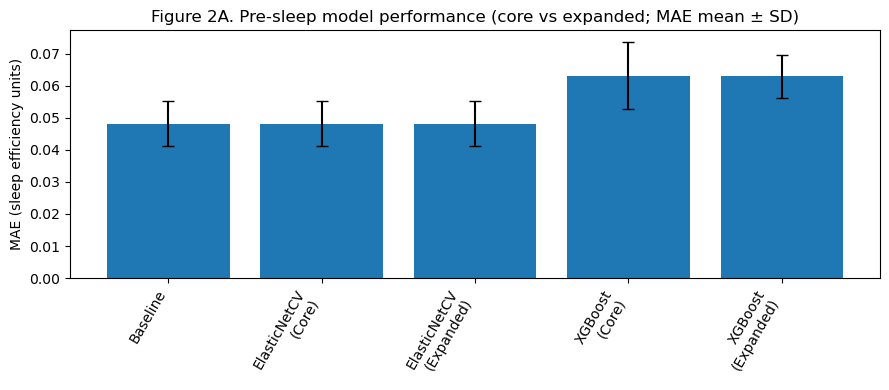

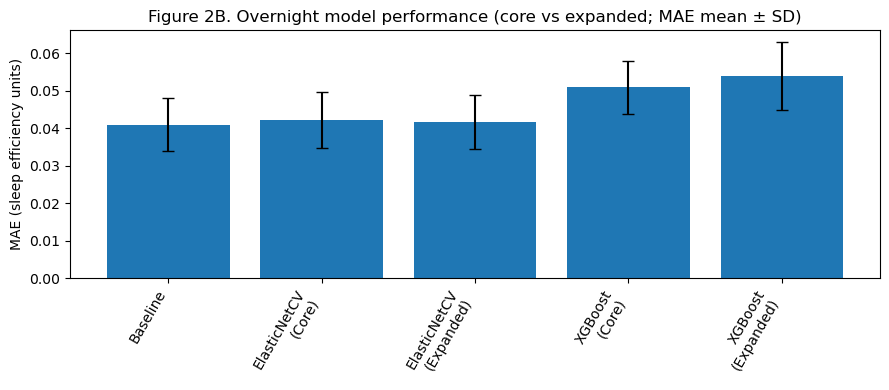

In [129]:
# MAE bar plot

def parse_mean_sd(s):
    # s looks like "0.0481 ± 0.0070"
    mean_str, sd_str = s.split("±")
    return float(mean_str.strip()), float(sd_str.strip())

# Figure 2A: Pre-sleep MAE (Baseline vs ElasticNetCV core vs XGBoost core)
# Extract MAE mean±SD from your pre-sleep table
# Pull MAE strings from your pre-sleep table
pre_base = table_pre_core_vs_exp.loc[
    table_pre_core_vs_exp["Model"].str.contains("Baseline"), "MAE (mean±SD)"
].iloc[0]

pre_enet_core = table_pre_core_vs_exp.loc[
    (table_pre_core_vs_exp["Model"]=="ElasticNetCV") & (table_pre_core_vs_exp["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

pre_enet_exp = table_pre_core_vs_exp.loc[
    (table_pre_core_vs_exp["Model"]=="ElasticNetCV") & (table_pre_core_vs_exp["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

pre_xgb_core = table_pre_core_vs_exp.loc[
    (table_pre_core_vs_exp["Model"]=="XGBoost") & (table_pre_core_vs_exp["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

pre_xgb_exp = table_pre_core_vs_exp.loc[
    (table_pre_core_vs_exp["Model"]=="XGBoost") & (table_pre_core_vs_exp["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

labels = ["Baseline", "ElasticNetCV\n(Core)", "ElasticNetCV\n(Expanded)", "XGBoost\n(Core)", "XGBoost\n(Expanded)"]
vals = [pre_base, pre_enet_core, pre_enet_exp, pre_xgb_core, pre_xgb_exp]

means, sds = zip(*[parse_mean_sd(v) for v in vals])

x = np.arange(len(labels))
plt.figure(figsize=(9,4))
plt.bar(x, means, yerr=sds, capsize=4)
plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("MAE (sleep efficiency units)")
plt.title("Figure 2A. Pre-sleep model performance (core vs expanded; MAE mean ± SD)")
plt.tight_layout()
plt.show()


# Figure 2B: Ov# Extract MAE mean±SD from your overnight table
# Pull MAE strings from your overnight table
ovr_base = table_ovr_core_vs_exp.loc[
    table_ovr_core_vs_exp["Model"].str.contains("Baseline"), "MAE (mean±SD)"
].iloc[0]

ovr_enet_core = table_ovr_core_vs_exp.loc[
    (table_ovr_core_vs_exp["Model"]=="ElasticNetCV") & (table_ovr_core_vs_exp["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

ovr_enet_exp = table_ovr_core_vs_exp.loc[
    (table_ovr_core_vs_exp["Model"]=="ElasticNetCV") & (table_ovr_core_vs_exp["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

ovr_xgb_core = table_ovr_core_vs_exp.loc[
    (table_ovr_core_vs_exp["Model"]=="XGBoost") & (table_ovr_core_vs_exp["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

ovr_xgb_exp = table_ovr_core_vs_exp.loc[
    (table_ovr_core_vs_exp["Model"]=="XGBoost") & (table_ovr_core_vs_exp["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

labels = ["Baseline", "ElasticNetCV\n(Core)", "ElasticNetCV\n(Expanded)", "XGBoost\n(Core)", "XGBoost\n(Expanded)"]
vals = [ovr_base, ovr_enet_core, ovr_enet_exp, ovr_xgb_core, ovr_xgb_exp]

means, sds = zip(*[parse_mean_sd(v) for v in vals])

x = np.arange(len(labels))
plt.figure(figsize=(9,4))
plt.bar(x, means, yerr=sds, capsize=4)
plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("MAE (sleep efficiency units)")
plt.title("Figure 2B. Overnight model performance (core vs expanded; MAE mean ± SD)")
plt.tight_layout()
plt.show()



## modeling sensitivity windows

In [133]:
# Drop participants with too few nights
# Pre-sleep sensitivity: keep participants with ≥2 nights
# Overnight sensitivity: keep participants with ≥3 nights

def retain_after_rules(night_cov, valid_col, k, min_nights, window_name):
    # keep nights that meet segment threshold
    tmp = night_cov.copy()
    tmp[valid_col] = tmp[valid_col].fillna(0)
    kept_nights = tmp[tmp[valid_col] >= k].copy()

    # keep participants with enough retained nights
    counts = kept_nights["deviceId"].value_counts()
    keep_ids = counts[counts >= min_nights].index
    final = kept_nights[kept_nights["deviceId"].isin(keep_ids)].copy()

    return {
        "Window": window_name,
        "k_segments": k,
        "min_nights_per_participant": min_nights,
        "Retained_nights": len(final),
        "Retained_participants": final["deviceId"].nunique(),
        "Median_nights_per_participant": final["deviceId"].value_counts().median() if len(final)>0 else 0
    }

summary = pd.DataFrame([
    retain_after_rules(night_cov, valid_col="pre_valid", k=10,  min_nights=2, window_name="Pre-sleep_sensitivity"),
    retain_after_rules(night_cov, valid_col="ovr_valid", k=15, min_nights=3, window_name="Overnight_sensitivity")
])

summary

,Window,k_segments,min_nights_per_participant,Retained_nights,Retained_participants,Median_nights_per_participant
0,Pre-sleep_sensitivity,10,2,88,14,5.0
1,Overnight_sensitivity,15,3,396,31,11.0


In [134]:
# modeling: GroupKFold CV on primaty datasets and run ElastiC NetCV + XGBoost with participant-wise folds
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error
import xgboost
from xgboost import XGBRegressor
print("xgboost version:", xgboost.__version__)


# Drop participants with too few nights
# Pre-sleep primary: keep participants with ≥2 nights (because median is 3)
# Overnight primary: keep participants with ≥3 nights
def filter_min_nights(df, min_nights):
    counts = df["deviceId"].value_counts()
    keep_ids = counts[counts >= min_nights].index
    return df[df["deviceId"].isin(keep_ids)].copy()

pre_sensitivity = filter_min_nights(pre_sleep_k10, min_nights=2)
ovr_sensitivity = filter_min_nights(overnight_k15, min_nights=3)

print("Pre-sleep sensitivity after >=3 nights:", pre_sensitivity.shape, pre_sensitivity["deviceId"].nunique())
print("Overnight sensitivity after >=3 nights:", ovr_sensitivity.shape, ovr_sensitivity["deviceId"].nunique())


xgboost version: 3.2.0
Pre-sleep sensitivity after >=3 nights: (88, 33) 14
Overnight sensitivity after >=3 nights: (396, 33) 31


In [135]:
# re-run sensitivity modeling using core features
n_splits_pre = 5 if pre_sensitivity["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_sensitivity["deviceId"].nunique() >= 25 else 4

res_pre_cv_sens = groupkfold_eval_enetcv_xgb(pre_sensitivity, core_features, n_splits=n_splits_pre)
res_ovr_cv_sens = groupkfold_eval_enetcv_xgb(ovr_sensitivity, core_features, n_splits=n_splits_ovr)

print("Pre-sleep ElasticNetCV:\n", summarize_cv(res_pre_cv_sens["ElasticNetCV"]))
print("Pre-sleep XGBoost:\n", summarize_cv(res_pre_cv_sens["XGBoost"]))

print("Overnight ElasticNetCV:\n", summarize_cv(res_ovr_cv_sens["ElasticNetCV"]))
print("Overnight XGBoost:\n", summarize_cv(res_ovr_cv_sens["XGBoost"]))


Pre-sleep ElasticNetCV:
          MAE    RMSE      R2
mean  0.0416  0.0543 -0.1292
std   0.0208  0.0266  0.1415
Pre-sleep XGBoost:
          MAE   RMSE      R2
mean  0.0530  0.070 -1.2680
std   0.0178  0.022  1.0195
Overnight ElasticNetCV:
          MAE    RMSE      R2
mean  0.0377  0.0559 -0.1652
std   0.0118  0.0180  0.1774
Overnight XGBoost:
          MAE    RMSE      R2
mean  0.0456  0.0652 -0.9490
std   0.0097  0.0118  1.3454


In [136]:
# run participant-wise modeling with expanded features using ElasticNetCV

res_pre_exp_sens = groupkfold_eval_enetcv_xgb(pre_sensitivity, expanded_features, n_splits=n_splits_pre)
res_ovr_exp_sens = groupkfold_eval_enetcv_xgb(ovr_sensitivity, expanded_features, n_splits=n_splits_ovr)

print("Pre-sleep ElasticNetCV (expanded):\n", summarize_cv(res_pre_exp_sens["ElasticNetCV"]))
print("Pre-sleep XGBoost (expanded):\n", summarize_cv(res_pre_exp_sens["XGBoost"]))

print("Overnight ElasticNetCV (expanded):\n", summarize_cv(res_pre_exp_sens["ElasticNetCV"]))
print("Overnight XGBoost (expanded):\n", summarize_cv(res_pre_exp_sens["XGBoost"]))

Pre-sleep ElasticNetCV (expanded):
          MAE    RMSE      R2
mean  0.0415  0.0541 -0.1231
std   0.0207  0.0264  0.1303
Pre-sleep XGBoost (expanded):
          MAE    RMSE      R2
mean  0.0571  0.0713 -1.3186
std   0.0183  0.0225  0.8918
Overnight ElasticNetCV (expanded):
          MAE    RMSE      R2
mean  0.0415  0.0541 -0.1231
std   0.0207  0.0264  0.1303
Overnight XGBoost (expanded):
          MAE    RMSE      R2
mean  0.0571  0.0713 -1.3186
std   0.0183  0.0225  0.8918


In [137]:
# run baseline and models for sensitivity windows
n_splits_pre = 5 if pre_sensitivity["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_sensitivity["deviceId"].nunique() >= 25 else 4

# Baselines
base_pre_sens = baseline_mean_groupkfold(pre_sensitivity, n_splits=n_splits_pre)
base_ovr_sens = baseline_mean_groupkfold(ovr_sensitivity, n_splits=n_splits_ovr)

# Models (already computed as res_pre_cv, res_ovr_cv)
# res_pre_cv: {"ElasticNetCV": df, "XGBoost": df}
# res_ovr_cv: {"ElasticNetCV": df, "XGBoost": df}


In [138]:
# Create a clean comparison table for core vs expanded and baseline
import pandas as pd

def format_mean_sd(df_metrics):
    m = df_metrics[["MAE","RMSE","R2"]].mean()
    s = df_metrics[["MAE","RMSE","R2"]].std()
    return {
        "MAE (mean±SD)": f"{m['MAE']:.4f} ± {s['MAE']:.4f}",
        "RMSE (mean±SD)": f"{m['RMSE']:.4f} ± {s['RMSE']:.4f}",
        "R2 (mean±SD)": f"{m['R2']:.4f} ± {s['R2']:.4f}",
    }
 # build comparison table for one window
def build_core_vs_exp_with_baseline(base_df, res_core, res_exp):
    rows = []

    # Baseline (same regardless of features)
    rows.append({
        "Model": "Baseline (mean predictor)",
        "Feature set": "-",
        **format_mean_sd(base_df)
    })

    # ElasticNetCV
    rows.append({
        "Model": "ElasticNetCV",
        "Feature set": "Core",
        **format_mean_sd(res_core["ElasticNetCV"])
    })
    rows.append({
        "Model": "ElasticNetCV",
        "Feature set": "Expanded",
        **format_mean_sd(res_exp["ElasticNetCV"])
    })

    # XGBoost
    rows.append({
        "Model": "XGBoost",
        "Feature set": "Core",
        **format_mean_sd(res_core["XGBoost"])
    })
    rows.append({
        "Model": "XGBoost",
        "Feature set": "Expanded",
        **format_mean_sd(res_exp["XGBoost"])
    })

    return pd.DataFrame(rows)

table_pre_core_vs_exp_sens = build_core_vs_exp_with_baseline(base_pre_sens, res_pre_cv_sens, res_pre_exp_sens)
table_ovr_core_vs_exp_sens = build_core_vs_exp_with_baseline(base_ovr_sens, res_ovr_cv_sens, res_ovr_exp_sens)

print("Pre-sleep-sensitivity core vs expanded (with baseline):")
display(table_pre_core_vs_exp_sens)

print("Overnight-sensitivity core vs expanded (with baseline):")
display(table_ovr_core_vs_exp_sens)


Pre-sleep-sensitivity core vs expanded (with baseline):


,Model,Feature set,MAE (mean±SD),RMSE (mean±SD),R2 (mean±SD)
0,Baseline (mean predictor),-,0.0415 ± 0.0207,0.0537 ± 0.0260,-0.1124 ± 0.1111
1,ElasticNetCV,Core,0.0416 ± 0.0208,0.0543 ± 0.0266,-0.1292 ± 0.1415
2,ElasticNetCV,Expanded,0.0415 ± 0.0207,0.0541 ± 0.0264,-0.1231 ± 0.1303
3,XGBoost,Core,0.0530 ± 0.0178,0.0700 ± 0.0220,-1.2680 ± 1.0195
4,XGBoost,Expanded,0.0571 ± 0.0183,0.0713 ± 0.0225,-1.3186 ± 0.8918


Overnight-sensitivity core vs expanded (with baseline):


,Model,Feature set,MAE (mean±SD),RMSE (mean±SD),R2 (mean±SD)
0,Baseline (mean predictor),-,0.0377 ± 0.0118,0.0559 ± 0.0180,-0.1652 ± 0.1774
1,ElasticNetCV,Core,0.0377 ± 0.0118,0.0559 ± 0.0180,-0.1652 ± 0.1774
2,ElasticNetCV,Expanded,0.0380 ± 0.0117,0.0561 ± 0.0180,-0.1718 ± 0.1707
3,XGBoost,Core,0.0456 ± 0.0097,0.0652 ± 0.0118,-0.9490 ± 1.3454
4,XGBoost,Expanded,0.0464 ± 0.0083,0.0667 ± 0.0107,-1.1910 ± 1.8478


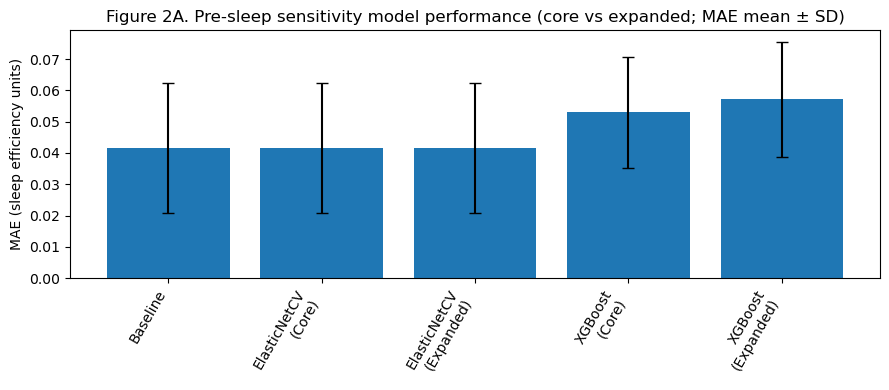

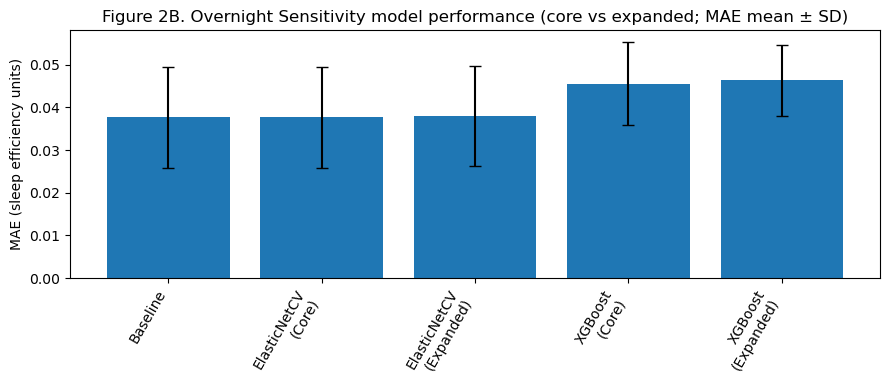

In [139]:
# MAE bar plot for sensitivity windows

def parse_mean_sd(s):
    # s looks like "0.0481 ± 0.0070"
    mean_str, sd_str = s.split("±")
    return float(mean_str.strip()), float(sd_str.strip())

# Figure 2A: Pre-sleep-sensivity MAE (Baseline vs ElasticNetCV core vs XGBoost core)
# Extract MAE mean±SD from your pre-sleep table
# Pull MAE strings from your pre-sleep table
pre_base_sens = table_pre_core_vs_exp_sens.loc[
    table_pre_core_vs_exp_sens["Model"].str.contains("Baseline"), "MAE (mean±SD)"
].iloc[0]

pre_enet_core_sens = table_pre_core_vs_exp_sens.loc[
    (table_pre_core_vs_exp_sens["Model"]=="ElasticNetCV") & (table_pre_core_vs_exp_sens["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

pre_enet_exp_sens = table_pre_core_vs_exp_sens.loc[
    (table_pre_core_vs_exp_sens["Model"]=="ElasticNetCV") & (table_pre_core_vs_exp_sens["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

pre_xgb_core_sens = table_pre_core_vs_exp_sens.loc[
    (table_pre_core_vs_exp_sens["Model"]=="XGBoost") & (table_pre_core_vs_exp_sens["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

pre_xgb_exp_sens = table_pre_core_vs_exp_sens.loc[
    (table_pre_core_vs_exp_sens["Model"]=="XGBoost") & (table_pre_core_vs_exp_sens["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

labels = ["Baseline", "ElasticNetCV\n(Core)", "ElasticNetCV\n(Expanded)", "XGBoost\n(Core)", "XGBoost\n(Expanded)"]
vals = [pre_base_sens, pre_enet_core_sens, pre_enet_exp_sens, pre_xgb_core_sens, pre_xgb_exp_sens]

means, sds = zip(*[parse_mean_sd(v) for v in vals])

x = np.arange(len(labels))
plt.figure(figsize=(9,4))
plt.bar(x, means, yerr=sds, capsize=4)
plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("MAE (sleep efficiency units)")
plt.title("Figure 2A. Pre-sleep sensitivity model performance (core vs expanded; MAE mean ± SD)")
plt.tight_layout()
plt.show()


# Figure 2B: Ov# Extract MAE mean±SD from your overnight table
# Pull MAE strings from your overnight table
ovr_base_sens = table_ovr_core_vs_exp_sens.loc[
    table_ovr_core_vs_exp_sens["Model"].str.contains("Baseline"), "MAE (mean±SD)"
].iloc[0]

ovr_enet_core_sens = table_ovr_core_vs_exp_sens.loc[
    (table_ovr_core_vs_exp_sens["Model"]=="ElasticNetCV") & (table_ovr_core_vs_exp_sens["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

ovr_enet_exp_sens = table_ovr_core_vs_exp_sens.loc[
    (table_ovr_core_vs_exp_sens["Model"]=="ElasticNetCV") & (table_ovr_core_vs_exp_sens["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

ovr_xgb_core_sens = table_ovr_core_vs_exp_sens.loc[
    (table_ovr_core_vs_exp_sens["Model"]=="XGBoost") & (table_ovr_core_vs_exp_sens["Feature set"]=="Core"),
    "MAE (mean±SD)"
].iloc[0]

ovr_xgb_exp_sens = table_ovr_core_vs_exp_sens.loc[
    (table_ovr_core_vs_exp_sens["Model"]=="XGBoost") & (table_ovr_core_vs_exp_sens["Feature set"]=="Expanded"),
    "MAE (mean±SD)"
].iloc[0]

labels = ["Baseline", "ElasticNetCV\n(Core)", "ElasticNetCV\n(Expanded)", "XGBoost\n(Core)", "XGBoost\n(Expanded)"]
vals = [ovr_base_sens, ovr_enet_core_sens, ovr_enet_exp_sens, ovr_xgb_core_sens, ovr_xgb_exp_sens]

means, sds = zip(*[parse_mean_sd(v) for v in vals])

x = np.arange(len(labels))
plt.figure(figsize=(9,4))
plt.bar(x, means, yerr=sds, capsize=4)
plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("MAE (sleep efficiency units)")
plt.title("Figure 2B. Overnight Sensitivity model performance (core vs expanded; MAE mean ± SD)")
plt.tight_layout()
plt.show()


#### Sensitivity analyses.
To assess whether conclusions depended on the feasibility thresholds used to construct the night-level datasets, we repeated model evaluation under stricter segment requirements (pre-sleep k=10; overnight k=15). Results were consistent with the primary analyses. In both windows, ElasticNetCV remained at baseline-level performance (pre-sleep sensitivity baseline MAE 0.0415±0.0207; ElasticNetCV MAE 0.0415–0.0416; overnight sensitivity baseline MAE 0.0377±0.0118; ElasticNetCV MAE 0.0377–0.0380), while XGBoost continued to show higher errors (pre-sleep MAE 0.0528–0.0577; overnight MAE 0.0456–0.0464). Expanded HRV features did not yield meaningful performance gains under these stricter thresholds. Overall, sensitivity analyses confirmed that the main findings—baseline-level performance for ElasticNetCV and poorer generalization for XGBoost—were robust to the choice of feasibility thresholds.
#### discussion
“Sensitivity analyses using stricter k thresholds produced the same qualitative pattern as the primary results, suggesting that the baseline-level performance is not an artifact of permissive feasibility filtering but reflects limited cross-person predictive signal in HRV-only features for sleep efficiency.

You might notice overnight sensitivity baseline MAE (0.0377) is smaller than primary overnight baseline (0.0410). That’s expected because:
stricter thresholds keep nights with more valid HRV segments, which likely correspond to cleaner, more regular nights, and may reduce noise/variance.
But the key point is: even in this cleaner subset, HRV still doesn’t beat baseline.

## Cluster

In [142]:
import os
import warnings

# Fix KMeans MKL warning on Windows (recommended by sklearn warning message)
os.environ["OMP_NUM_THREADS"] = "1"

# Silence these specific warnings (optional)
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster")
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

survey = pd.read_csv("survey.csv")

# keep needed columns
clust_df = survey[["deviceId", "PHQ9_1", "GAD7_1", "ISI_1"]].dropna().copy()

X = clust_df[["PHQ9_1", "GAD7_1", "ISI_1"]].values
Xz = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=20)
clust_df["cluster"] = kmeans.fit_predict(Xz)

# cluster summary for interpretation
cluster_summary = clust_df.groupby("cluster")[["PHQ9_1", "GAD7_1", "ISI_1"]].mean().round(2)
cluster_counts = clust_df["cluster"].value_counts().sort_index()

cluster_summary, cluster_counts

(         PHQ9_1  GAD7_1  ISI_1
 cluster                       
 0          1.11    1.04   4.41
 1          5.83    4.28   9.83
 2         11.00   10.75  16.75,
 cluster
 0    27
 1    18
 2     4
 Name: count, dtype: int64)

In [166]:
# Replace cluster labels 0/1/2 with meaningful health profile names
profile_map = {
    0: "Low symptom",
    1: "Moderate symptom",
    2: "High symptom"
}

clust_df["profile"] = clust_df["cluster"].map(profile_map)
clust_df[["deviceId", "cluster", "profile"]].head()
profile_map = {
    0: "Low symptom",
    1: "Moderate symptom",
    2: "High symptom"
}

clust_df["profile"] = clust_df["cluster"].map(profile_map)
clust_df[["deviceId", "cluster", "profile"]].head()

,deviceId,cluster,profile
0,pm96,0,Low symptom
1,vc10,1,Moderate symptom
2,pg18,1,Moderate symptom
3,nd56,0,Low symptom
4,vs14,2,High symptom


In [170]:
# Merge profiles into your night-level datasets
# Merge into your final modeling datasets
pre_main_prof = pre_main.merge(clust_df[["deviceId", "profile"]], on="deviceId", how="left")
ovr_main_prof = ovr_main.merge(clust_df[["deviceId", "profile"]], on="deviceId", how="left")

print("Pre-sleep nights with profile:", pre_main_prof["profile"].notna().mean())
print("Overnight nights with profile:", ovr_main_prof["profile"].notna().mean())
pre_main_prof.head()
ovr_main_prof.head()

Pre-sleep nights with profile: 1.0
Overnight nights with profile: 1.0


,deviceId,date,sleep_efficiency,n_valid_segments,window,k_rule,HR_mean,HR_median,HR_sd,sdnn_mean,...,lf_mean,lf_median,lf_sd,hf_mean,hf_median,hf_sd,lf/hf_mean,lf/hf_median,lf/hf_sd,profile
0,pm96,2021-03-09,0.866667,24,overnight,10,81.942175,82.580031,4.721774,71.975587,...,1260.549269,1179.293753,543.001331,1300.036471,1313.554894,607.874135,1.203345,0.926902,0.895950,Low symptom
1,pm96,2021-03-10,0.914894,33,overnight,10,78.067997,78.912942,6.217562,74.567160,...,1044.293501,962.469041,572.466967,1310.463989,1135.974376,683.867345,1.005449,0.800452,0.713131,Low symptom
2,pm96,2021-03-11,0.930233,15,overnight,10,82.121532,82.655346,8.521768,69.439401,...,1189.945822,731.840306,1026.295545,989.577631,936.664835,447.300181,1.296793,0.879991,1.068477,Low symptom
3,pm96,2021-03-12,0.931818,10,overnight,10,67.748003,67.877409,1.200908,79.189636,...,994.694192,932.486970,506.102029,1597.903254,1595.366929,655.748241,0.890483,0.546968,1.016192,Low symptom
4,pm96,2021-03-13,0.947368,25,overnight,10,90.369032,89.200832,7.213977,66.710261,...,2582.156493,678.260018,9058.446509,4146.368255,929.292883,14327.527817,0.962957,0.717239,0.849533,Low symptom


In [172]:
# save as CSV files
pre_main_prof.to_csv("pre_sleep_night_level_main_profile.csv", index=False)
ovr_main_prof.to_csv("overnight_night_level_main_profile.csv", index=False)

In [176]:
# Main cluster result: participant-level mean sleep efficiency by profile

# participant-level mean SE
pre_person_se = pre_main_prof.groupby(["deviceId","profile"])["sleep_efficiency"].mean().reset_index()
ovr_person_se = ovr_main_prof.groupby(["deviceId","profile"])["sleep_efficiency"].mean().reset_index()

# summary table
pre_se_summary = pre_person_se.groupby("profile")["sleep_efficiency"].agg(
    n_participants="count", mean="mean", sd="std"
).round(4)

ovr_se_summary = ovr_person_se.groupby("profile")["sleep_efficiency"].agg(
    n_participants="count", mean="mean", sd="std"
).round(4)

print("Pre-sleep: participant mean SE by profile")
display(pre_se_summary)

print("Overnight: participant mean SE by profile")
display(ovr_se_summary)

Pre-sleep: participant mean SE by profile


,n_participants,mean,sd
profile,,,
High symptom,2,0.8422,0.0341
Low symptom,13,0.9427,0.0440
Moderate symptom,10,0.9051,0.0813


Overnight: participant mean SE by profile


,n_participants,mean,sd
profile,,,
High symptom,3,0.8840,0.0360
Low symptom,22,0.9510,0.0362
Moderate symptom,15,0.9163,0.0701


In [178]:
#statistics test
from scipy.stats import kruskal
def kruskal_by_profile(person_df):
    groups = [g["sleep_efficiency"].values for _, g in person_df.groupby("profile")]
    return kruskal(*groups)

print("Pre-sleep Kruskal–Wallis:", kruskal_by_profile(pre_person_se))
print("Overnight Kruskal–Wallis:", kruskal_by_profile(ovr_person_se))

Pre-sleep Kruskal–Wallis: KruskalResult(statistic=4.487453754402593, pvalue=0.10606248502253311)
Overnight Kruskal–Wallis: KruskalResult(statistic=5.968248337028825, pvalue=0.05058378702721042)


C:\Users\yanch\AppData\Local\Temp\ipykernel_63252\3022960810.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


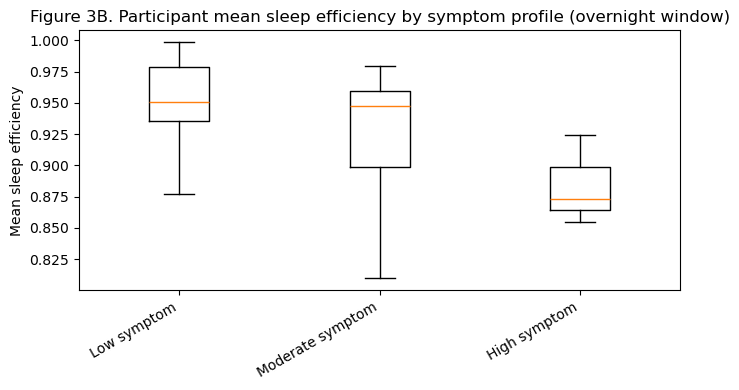

C:\Users\yanch\AppData\Local\Temp\ipykernel_63252\3022960810.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


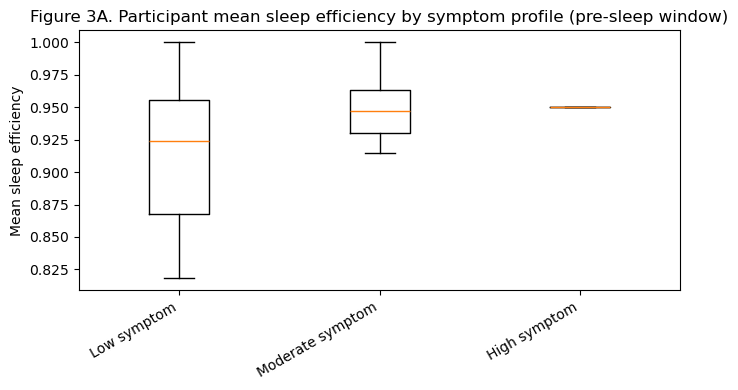

In [202]:
# Figure: boxplot of participant mean sleep efficiency by profile
import matplotlib.pyplot as plt

order = ["Low symptom", "Moderate symptom", "High symptom"]  # adjust if your labels differ

plt.figure(figsize=(7,4))
data = [ovr_person_se.loc[ovr_person_se["profile"]==p, "sleep_efficiency"].values for p in order if p in ovr_person_se["profile"].unique()]
labels = [p for p in order if p in ovr_person_se["profile"].unique()]

plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Figure 3B. Participant mean sleep efficiency by symptom profile (overnight window)")
plt.ylabel("Mean sleep efficiency")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
data = [pre_person_se.loc[ovr_person_se["profile"]==p, "sleep_efficiency"].values for p in order if p in ovr_person_se["profile"].unique()]
labels = [p for p in order if p in ovr_person_se["profile"].unique()]

plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Figure 3A. Participant mean sleep efficiency by symptom profile (pre-sleep window)")
plt.ylabel("Mean sleep efficiency")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [184]:
## Compute how many retained nights each participant has, then summarize by profile
# nights retained per participant (within each window)
pre_nights_pp = pre_main_prof.groupby(["deviceId","profile"]).size().reset_index(name="n_nights")
ovr_nights_pp = ovr_main_prof.groupby(["deviceId","profile"]).size().reset_index(name="n_nights")

pre_feas = pre_nights_pp.groupby("profile")["n_nights"].agg(
    n_participants="count", median="median", mean="mean", min="min", max="max"
).round(2)

ovr_feas = ovr_nights_pp.groupby("profile")["n_nights"].agg(
    n_participants="count", median="median", mean="mean", min="min", max="max"
).round(2)

print("Pre-sleep feasibility (retained nights per participant) by profile")
display(pre_feas)

print("Overnight feasibility (retained nights per participant) by profile")
display(ovr_feas)

Pre-sleep feasibility (retained nights per participant) by profile


,n_participants,median,mean,min,max
profile,,,,,
High symptom,2,6.0,6.0,3,9
Low symptom,13,9.0,10.0,2,24
Moderate symptom,10,4.0,6.0,2,16


Overnight feasibility (retained nights per participant) by profile


,n_participants,median,mean,min,max
profile,,,,,
High symptom,3,16.0,14.33,11,16
Low symptom,22,18.0,15.86,3,26
Moderate symptom,15,8.0,10.80,4,26


In [194]:
# dd profile dummies
import pandas as pd

def add_profile_dummies(df, profile_col="profile"):
    df2 = df.copy()
    dummies = pd.get_dummies(df2[profile_col], prefix="profile", drop_first=True)
    return pd.concat([df2, dummies], axis=1)

ovr_prof2 = add_profile_dummies(ovr_main_prof)  # your overnight dataset with profile merged
pre_prof2 = add_profile_dummies(pre_main_prof)

In [195]:
# define features with profile
profile_cols_ovr = [c for c in ovr_prof2.columns if c.startswith("profile_")]
profile_cols_pre = [c for c in pre_prof2.columns if c.startswith("profile_")]

core_plus_profile_ovr = core_features + profile_cols_ovr
core_plus_profile_pre = core_features + profile_cols_pre

In [196]:
# run ElasticNetCV again (same CV)
n_splits_pre = 5 if pre_prof2["deviceId"].nunique() >= 25 else 4
n_splits_ovr = 5 if ovr_prof2["deviceId"].nunique() >= 25 else 4

res_pre_hrv = groupkfold_eval_enetcv_xgb(pre_prof2, core_features, n_splits=n_splits_pre)
res_pre_hrv_prof = groupkfold_eval_enetcv_xgb(pre_prof2, core_plus_profile_pre, n_splits=n_splits_pre)

res_ovr_hrv = groupkfold_eval_enetcv_xgb(ovr_prof2, core_features, n_splits=n_splits_ovr)
res_ovr_hrv_prof = groupkfold_eval_enetcv_xgb(ovr_prof2, core_plus_profile_ovr, n_splits=n_splits_ovr)

print("Pre HRV-only ElasticNetCV:\n", summarize_cv(res_pre_hrv["ElasticNetCV"]))
print("Pre HRV+profile ElasticNetCV:\n", summarize_cv(res_pre_hrv_prof["ElasticNetCV"]))

print("Overnight HRV-only ElasticNetCV:\n", summarize_cv(res_ovr_hrv["ElasticNetCV"]))
print("Overnight HRV+profile ElasticNetCV:\n", summarize_cv(res_ovr_hrv_prof["ElasticNetCV"]))

Pre HRV-only ElasticNetCV:
          MAE    RMSE      R2
mean  0.0481  0.0710 -0.0993
std   0.0070  0.0167  0.1213
Pre HRV+profile ElasticNetCV:
          MAE    RMSE      R2
mean  0.0488  0.0722 -0.1387
std   0.0077  0.0169  0.1668
Overnight HRV-only ElasticNetCV:
          MAE    RMSE      R2
mean  0.0422  0.0648 -0.1214
std   0.0074  0.0136  0.1551
Overnight HRV+profile ElasticNetCV:
          MAE    RMSE      R2
mean  0.0423  0.0646 -0.1158
std   0.0071  0.0139  0.1949
